# Microstructure AI concepts lab

**A materials-science laboratory for inference, representation, generation, and action**

This notebook uses one process–structure–property system throughout. A procedural
simulator supplies known causal variables and property equations; the real UHCS SEM
corpus supplies a reality check. The simulator is pedagogical—not a phase-field model,
kinetic model, or substitute for measured properties.

<div style="border:1px solid #d99;padding:0.6em 1em;background:#fff8f6">
<b>Evidence labels used here</b><br>
🟦 <b>SYNTHETIC GROUND TRUTH</b>: the notebook knows the generating mechanism.<br>
🟩 <b>REAL UNLABELLED / PROCESS-LABELLED</b>: genuine SEM images and metadata.<br>
🟨 <b>MEASURED HARDNESS</b>: only seven UHCS sample conditions; not enough for a definitive model.<br>
🟧 <b>DISTANT HARDNESS LABEL</b>: same study/condition, not proven to be the exact tested region.
</div>

Autoregressive and diffusion models are included because they are important generative
ML methods. They are adjacent to—not inherently instances of—neuroscience-inspired ML.

### How to use this notebook as a course

This is deliberately one connected story rather than fifteen unrelated tutorials.

1. **First pass — read and predict.** Read each purple *Before you run* box, make the
   requested prediction, then inspect the saved output without rerunning anything.
2. **Second pass — rerun locally.** Change one clearly identified quantity—noise,
   precision, held-out regime, sampling temperature, or constraint—and rerun only that
   part plus its prerequisites.
3. **Third pass — try to falsify it.** Use the interpretation checkpoint to design a
   result that would prove the current story wrong. This is the scientific pass.

Suggested routes:

- **Inference foundations:** Parts 0–4.
- **Learning representations and beliefs:** Parts 5–7.
- **Choosing actions and generating structures:** Parts 8–10.
- **Reliability, dynamics, and physical validity:** Parts 11–14.

When an output surprises you, ask four questions in order: **What data did it see? What
was held out? What objective was optimised? What inference procedure produced this
answer?** Most apparent contradictions between models disappear once those four are explicit.

| In the code | In the mathematics | In materials science |
|---|---|---|
| array/tensor | a collection of variables | images, process settings, states, properties |
| model parameters | $\theta$ or $\phi$ | learned empirical relationships |
| forward pass | evaluate $f_\theta(x)$ | predict structure or properties |
| loss | negative score / free-energy proxy | what counts as a bad explanation |
| optimiser step | update parameters or beliefs | improve a model or revise a state hypothesis |

## Configuration and reproducibility

`fast_demo=True` is the tested CPU path. It still trains every small model, including
autoregressive and diffusion models. Increase epochs or resolution only after the whole
narrative makes sense.

In [1]:
from __future__ import annotations

import math
import os
import random
import sqlite3
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display
from PIL import Image
from scipy import ndimage
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    pairwise_distances,
    r2_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

@dataclass(frozen=True)
class LabConfig:
    seed: int = 17
    image_size: int = 64
    n_samples: int = 1_000
    batch_size: int = 64
    epochs: int = 10
    device: str = "cpu"       # change to "mps" on Apple Silicon if desired
    fast_demo: bool = True
    run_optional_heavy: bool = False
    show_shapes: bool = True

CONFIG = LabConfig()

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "microhard"]
    for candidate in candidates:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find the microhard project root. Run this notebook from the repo "
        "or its notebooks directory."
    )

seed_everything(CONFIG.seed)
PROJECT_ROOT = resolve_project_root()
DEVICE = torch.device(CONFIG.device)
if DEVICE.type == "mps" and not torch.backends.mps.is_available():
    raise RuntimeError("CONFIG.device='mps', but MPS is unavailable; use 'cpu'.")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4), "axes.titlesize": 11})
pd.set_option("display.max_columns", 30)
print(f"project={PROJECT_ROOT}")
print(f"torch={torch.__version__} | device={DEVICE} | fast_demo={CONFIG.fast_demo}")

project=/Users/jameshansen/Microstructural prediction/microhard
torch=2.13.0 | device=cpu | fast_demo=True


### How to read the equations

- $\mathbb{E}_{q}[\cdot]$: average using distribution $q$.
- $\log p(\cdot)$: log probability or model score.
- $D_{KL}$: mismatch between two distributions.
- $\nabla$: direction of fastest increase; $-\nabla$ is a descent direction.
- $p(a\mid b)$: probability of $a$ **given** $b$.
- A subscript on an expectation names the averaging distribution.
- $\dot z$: rate of change of $z$; $\hat y$ or $\bar y$: estimate/prediction.

The helper below forces every major equation to identify symbols, shapes, random
quantities, fixed quantities, the optimisation target, and its materials meaning.

In [2]:
def explain_equation(
    equation: str,
    symbols: dict[str, str],
    shapes: dict[str, str],
    *,
    random: str,
    fixed: str,
    optimised: str,
    materials_analogy: str,
) -> None:
    rows = "\n".join(
        f"- **${key}$** — {meaning}; shape `{shapes.get(key, 'scalar')}`"
        for key, meaning in symbols.items()
    )
    display(Markdown(
        f"### Equation lens\n\n$$ {equation} $$\n\n{rows}\n\n"
        f"- **Random:** {random}\n- **Fixed/observed:** {fixed}\n"
        f"- **Optimised:** {optimised}\n- **Materials interpretation:** {materials_analogy}"
    ))

explain_equation(
    r"\hat{y}=f_\theta(x)",
    {"x": "image or morphology features", r"\hat y": "predicted property", r"\theta": "model parameters"},
    {"x": "[batch, channels, height, width] or [batch, features]", r"\hat y": "[batch, 3]", r"\theta": "model-dependent"},
    random="The sampled material/image and measurement noise.",
    fixed="The observed input x during a forward pass.",
    optimised="Parameters θ during training.",
    materials_analogy="Infer yield strength, hardness, and ductility from observed structure."
)

### Equation lens

$$ \hat{y}=f_\theta(x) $$

- **$x$** — image or morphology features; shape `[batch, channels, height, width] or [batch, features]`
- **$\hat y$** — predicted property; shape `[batch, 3]`
- **$\theta$** — model parameters; shape `model-dependent`

- **Random:** The sampled material/image and measurement noise.
- **Fixed/observed:** The observed input x during a forward pass.
- **Optimised:** Parameters θ during training.
- **Materials interpretation:** Infer yield strength, hardness, and ductility from observed structure.

## Part 0 — Orientation: one coherent process–structure–property world

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

**Mental model.** Keep four kinds of quantity separate: processing choices, hidden
material state, measured image evidence, and target properties. The arrows describe a
proposed causal direction; a predictive model may run in the opposite direction without
reversing causality.

**Follow the code.** `make_synthetic_dataset` samples processing regimes, computes
interpretable hidden variables, renders an image, and evaluates fixed property equations.
The real-data cell then inventories UHCS without changing it.

**Pause and predict.** Which held-out regime should be hardest? Expect `R4_hot-fast_OOD`:
its temperature, cooling, phase fraction, porosity, and yield distribution jointly differ
from the development regimes. Also predict which visual details the procedural renderer
cannot reproduce from five scalar latents.

In [3]:
def sigmoid(x: np.ndarray | float) -> np.ndarray | float:
    return 1.0 / (1.0 + np.exp(-x))

REGIME_NAMES = np.array([
    "R0_low-C_cool", "R1_low-C_fast", "R2_mid-C", "R3_high-C",
    "R4_hot-fast_OOD",
])

def render_microstructure(row: pd.Series, rng: np.random.Generator, size: int) -> np.ndarray:
    # Procedural two-phase/grain texture; useful, but not a physical simulator.
    grain = float(row.grain_size)
    anis = float(row.anisotropy)
    sigma_y = np.clip(grain / 4.5 * (1.0 + anis), 0.8, 7.0)
    sigma_x = np.clip(grain / 4.5 / (1.0 + anis), 0.8, 7.0)
    field = ndimage.gaussian_filter(
        rng.normal(size=(size, size)), sigma=(sigma_y, sigma_x), mode="wrap"
    )
    field = (field - field.mean()) / (field.std() + 1e-6)
    threshold = np.quantile(field, 1.0 - float(row.phase_fraction))
    phase = field > threshold

    image = 0.28 + 0.48 * phase + 0.10 * np.tanh(field)
    boundaries = ndimage.morphological_gradient(phase.astype(float), size=(3, 3))
    image += 0.10 * boundaries

    pore_field = ndimage.gaussian_filter(rng.normal(size=(size, size)), 0.8)
    pore_mask = pore_field < np.quantile(pore_field, np.clip(row.porosity, 0.002, 0.25))
    image[pore_mask] *= 0.10

    yy, xx = np.mgrid[:size, :size]
    for _ in range(int(row.defect_density)):
        angle = rng.uniform(0, np.pi)
        offset = rng.uniform(-0.6 * size, 0.6 * size)
        distance = np.abs(
            (xx - size / 2) * np.sin(angle)
            - (yy - size / 2) * np.cos(angle) - offset
        )
        image[distance < rng.uniform(0.35, 0.8)] *= rng.uniform(0.15, 0.45)

    image += rng.normal(0, 0.035, size=image.shape)
    return np.clip(image, 0.0, 1.0).astype(np.float32)

def make_synthetic_dataset(config: LabConfig) -> tuple[pd.DataFrame, np.ndarray]:
    rng = np.random.default_rng(config.seed)
    n = config.n_samples
    regime_id = np.arange(n) % len(REGIME_NAMES)
    rng.shuffle(regime_id)
    composition = np.array([0.18, 0.28, 0.42, 0.58, 0.47])[regime_id]
    temperature = np.array([740, 790, 835, 875, 955])[regime_id] + rng.normal(0, 18, n)
    log_cooling = np.array([-0.4, 1.0, 0.35, 0.0, 1.4])[regime_id] + rng.normal(0, 0.28, n)
    cooling_rate = np.exp(log_cooling)

    grain_size = np.clip(
        5.0 + 0.030 * (temperature - 680) + 7.0 / (cooling_rate + 0.7)
        + 2.5 * composition + rng.normal(0, 0.9, n), 4.0, 28.0
    )
    phase_fraction = np.clip(sigmoid(
        -1.7 + 2.0 * composition + 0.50 * log_cooling
        + 0.003 * (temperature - 820) + rng.normal(0, 0.22, n)
    ), 0.04, 0.94)
    porosity = np.clip(sigmoid(
        -4.6 + 0.010 * np.abs(temperature - 835)
        + 0.22 * regime_id + rng.normal(0, 0.30, n)
    ), 0.003, 0.30)
    anisotropy = np.clip(
        0.10 + 0.13 * regime_id + 0.14 * np.maximum(log_cooling, 0)
        + rng.normal(0, 0.07, n), 0.0, 0.95
    )
    defect_density = rng.poisson(0.5 + 5.5 * porosity + 1.2 * anisotropy).astype(float)

    yield_strength = (
        330 + 1_150 / np.sqrt(grain_size) + 510 * phase_fraction
        - 1_050 * porosity + 75 * anisotropy
        - 22 * defect_density + 90 * phase_fraction * np.tanh(log_cooling)
        + 28 * np.sin(temperature / 65) + rng.normal(0, 24, n)
    )
    hardness = (
        55 + 0.29 * yield_strength + 125 * phase_fraction ** 1.6
        + 18 * anisotropy - 70 * porosity + rng.normal(0, 10, n)
    )
    ductility = np.clip(
        36 - 0.016 * yield_strength - 7.5 * phase_fraction - 17 * porosity
        + 0.30 * grain_size - 0.8 * defect_density
        + 2.0 * np.cos(temperature / 90) + rng.normal(0, 1.3, n), 1.5, 38
    )

    frame = pd.DataFrame({
        "sample_id": np.arange(n),
        "batch_id": [f"R{r}-B{i // 10:03d}" for i, r in enumerate(regime_id)],
        "regime_id": regime_id,
        "regime": REGIME_NAMES[regime_id],
        "composition": composition,
        "processing_temperature": temperature,
        "cooling_rate": cooling_rate,
        "grain_size": grain_size,
        "phase_fraction": phase_fraction,
        "porosity": porosity,
        "anisotropy": anisotropy,
        "defect_density": defect_density,
        "yield_strength": yield_strength,
        "hardness": hardness,
        "ductility": ductility,
    })
    images = np.stack([
        render_microstructure(row, np.random.default_rng(config.seed + int(row.sample_id)), config.image_size)
        for _, row in frame.iterrows()
    ])[:, None]
    assert images.shape == (n, 1, config.image_size, config.image_size)
    assert np.isfinite(images).all() and np.isfinite(frame.select_dtypes("number")).all().all()
    return frame, images

synthetic, images = make_synthetic_dataset(CONFIG)
print("metadata", synthetic.shape, "images", images.shape, images.dtype)
synthetic.groupby("regime")[["grain_size", "phase_fraction", "porosity", "yield_strength"]].mean().round(2)

metadata (1000, 15) images (1000, 1, 64, 64) float32


,grain_size,phase_fraction,porosity,yield_strength
regime,,,,
R0_low-C_cool,12.45,0.15,0.03,665.82
R1_low-C_fast,11.19,0.33,0.02,839.47
R2_mid-C,14.13,0.36,0.02,825.70
R3_high-C,16.65,0.40,0.03,815.89
R4_hot-fast_OOD,15.90,0.59,0.08,921.44


In [4]:
def discover_repo_data(root: Path) -> pd.DataFrame:
    data_root = root / "data"
    suffixes = {".tif", ".tiff", ".png", ".jpg", ".jpeg", ".csv", ".json", ".parquet", ".xlsx"}
    rows = []
    for path in data_root.rglob("*"):
        if path.is_file() and path.suffix.lower() in suffixes:
            rows.append({"suffix": path.suffix.lower(), "path": str(path.relative_to(root))})
    return pd.DataFrame(rows)

discovered = discover_repo_data(PROJECT_ROOT)
print(discovered.groupby("suffix").size().rename("files").to_string())

sqlite_path = PROJECT_ROOT / "data" / "microstructures.sqlite"
with sqlite3.connect(sqlite_path) as connection:
    real_meta = pd.read_sql_query(
        '''SELECT m.micrograph_id,m.path,m.magnification,m.sample_key,
                  s.label AS sample_label,s.anneal_temperature,s.anneal_time,s.cool_method
           FROM micrograph m LEFT JOIN sample s ON m.sample_key=s.sample_id''',
        connection,
    )
real_meta["image_path"] = real_meta["path"].map(
    lambda p: PROJECT_ROOT / "data" / "micrographs" / Path(str(p)).name
)
real_meta = real_meta[real_meta.image_path.map(Path.exists)].reset_index(drop=True)
print(f"real images on disk={len(real_meta):,}; linked physical samples={real_meta.sample_key.nunique()}")
print("Real targets present: seven UHCS hardness conditions; no yield-strength or ductility labels.")

suffix
.csv       4
.jpg      16
.json      1
.png      73
.tif     939
real images on disk=961; linked physical samples=43
Real targets present: seven UHCS hardness conditions; no yield-strength or ductility labels.


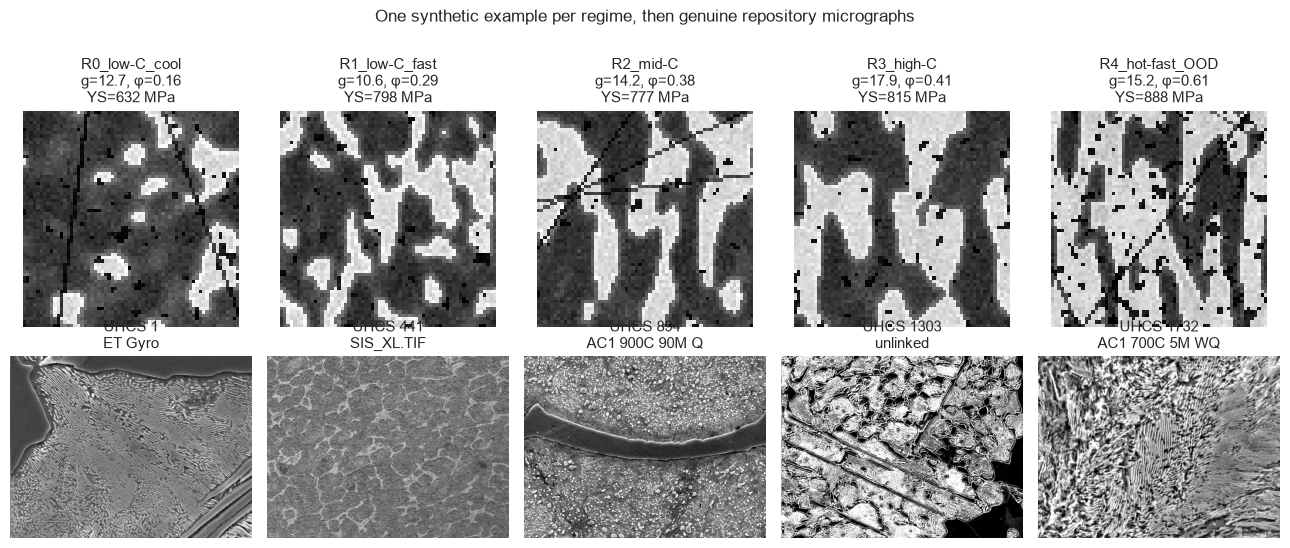

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for regime_id, ax in enumerate(axes[0]):
    idx = synthetic.index[synthetic.regime_id == regime_id][0]
    ax.imshow(images[idx, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"{synthetic.loc[idx, 'regime']}\n"
        f"g={synthetic.loc[idx, 'grain_size']:.1f}, φ={synthetic.loc[idx, 'phase_fraction']:.2f}\n"
        f"YS={synthetic.loc[idx, 'yield_strength']:.0f} MPa"
    )
    ax.axis("off")

real_choices = np.linspace(0, len(real_meta) - 1, 5, dtype=int)
for row_i, ax in zip(real_choices, axes[1]):
    row = real_meta.iloc[row_i]
    image = np.asarray(Image.open(row.image_path).convert("L"))
    ax.imshow(image, cmap="gray")
    sample_title = row.sample_label if pd.notna(row.sample_label) else "unlinked"
    ax.set_title(f"UHCS {row.micrograph_id}\n{sample_title}")
    ax.axis("off")
axes[0, 0].set_ylabel("SYNTHETIC", fontsize=11)
axes[1, 0].set_ylabel("REAL UHCS", fontsize=11)
plt.suptitle("One synthetic example per regime, then genuine repository micrographs", y=1.02)
plt.tight_layout()
plt.show()

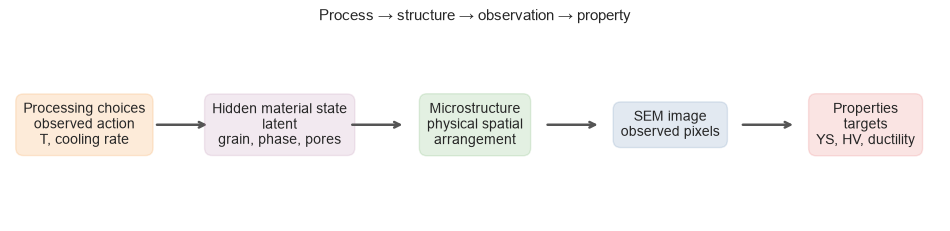

,role,variables
0,actions / choices,"temperature, cooling rate"
1,hidden state,"grain size, phase fraction, porosity, anisotro..."
2,observations,SEM pixels and extracted morphology
3,targets,"yield strength, hardness, ductility"


In [6]:
fig, ax = plt.subplots(figsize=(12, 2.5))
labels = [
    ("Processing choices", "observed action\nT, cooling rate"),
    ("Hidden material state", "latent\ngrain, phase, pores"),
    ("Microstructure", "physical spatial\narrangement"),
    ("SEM image", "observed pixels"),
    ("Properties", "targets\nYS, HV, ductility"),
]
xs = np.linspace(0.08, 0.92, len(labels))
colours = ["#F58518", "#B279A2", "#54A24B", "#4C78A8", "#E45756"]
for i, ((title, sub), x, colour) in enumerate(zip(labels, xs, colours)):
    ax.text(x, 0.5, f"{title}\n{sub}", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=.55", fc=colour, alpha=.16, ec=colour))
    if i < len(labels) - 1:
        ax.annotate("", (xs[i + 1] - .075, .5), (x + .075, .5),
                    arrowprops=dict(arrowstyle="->", lw=1.8, color="#555"))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.set_title("Process → structure → observation → property")
plt.show()

variable_roles = pd.DataFrame({
    "role": ["actions / choices", "hidden state", "observations", "targets"],
    "variables": [
        "temperature, cooling rate", "grain size, phase fraction, porosity, anisotropy, defects",
        "SEM pixels and extracted morphology", "yield strength, hardness, ductility",
    ],
})
variable_roles

### Compact glossary

| Term | Microstructure meaning |
|---|---|
| Generative model | Describes how hidden structure could produce images/properties; can often simulate samples. |
| Discriminative model | Directly maps an observed image/features to a property or class. |
| Latent variable | An unobserved cause such as phase state or effective grain scale. |
| Prior | Beliefs about plausible structures before seeing this image. |
| Likelihood | How compatible an image is with a proposed hidden structure. |
| Posterior | Updated beliefs about hidden structure after observing evidence. |
| Prediction error | Difference between observed and model-predicted pixels, features, or properties. |
| Precision | Inverse uncertainty; it determines which errors receive more weight. |
| Entropy | Uncertainty or spread in a distribution over structures/outcomes. |
| KL divergence | Directional mismatch between two probability distributions. |
| Free energy | A tractable objective balancing data fit against implausible/complex beliefs. |
| Expected free energy | A planning score combining preferred outcomes and useful information, under a stated convention. |
| Markov chain | A state process whose next-state distribution depends only on its current state. |
| Markov blanket | In a graph, the local variables that shield a node from the rest when conditioned upon. |
| Autoregressive model | Generates discrete image tokens sequentially, conditioning on preceding tokens. |
| Diffusion model | Learns to reverse gradual noising, producing one of many possible structures. |

**Terminology caution:** a graphical-model Markov blanket and a dynamical Markov
blanket in active-inference theory are related ideas, not automatically the same object.

<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** The top image row shows controlled synthetic variation; the
bottom row shows that real UHCS texture is richer, multiscale, and acquisition-dependent.
That visual mismatch is not cosmetic—it limits transfer from every later synthetic result.

**Connection to this repository.** Real UHCS processing metadata can supervise
temperature/cooling studies and its 961 images can train representations. Only seven
conditions have measured hardness, so synthetic yield and ductility remain learning aids.

**Guided exercise.** Hold processing fixed and vary only porosity in the generator.
Before running, sketch how yield, hardness, ductility, mean intensity, and edge density
should change. A mismatch reveals either a rendering assumption or a feature limitation.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> The lab now has explicit actions, hidden state, pixels, and targets with known equations.<br>
<b>What did it fail to learn?</b> The procedural images omit true phase kinetics, crystallography, scale-bar effects, and instrument physics.<br>
<b>What would falsify our interpretation?</b> A model that succeeds synthetically but fails on grouped real samples shows the simulator taught the wrong invariances.<br>
<b>What should I try next?</b> Change one causal equation and predict which plots should move before rerunning.
</div>

## Part 1 — Baseline scientific modelling

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** An engineered-feature model asks two separate questions: can we
measure morphology from pixels, and can those measurements predict properties? Errors
from the first stage propagate into the second.

**Follow the code.** The feature function converts each image to nine scalars. The split
first removes an entire regime, then separates remaining physical batches into training
and validation. Linear regression tests approximate additivity; a forest tests nonlinear
thresholds/interactions; the MLP tests a smooth learned nonlinear mapping.

**Pause and predict.** Validation should outperform the held-out regime. Linear
regression may extrapolate more gracefully than trees even when trees interpolate better,
because a tree cannot continue a learned slope beyond its training support.

We first expose morphology explicitly. This creates an interpretable scientific baseline
before asking neural networks to discover representations. Splits respect processing
batches, and the entire `R4_hot-fast_OOD` regime is held out.

In [7]:
MORPH_NAMES = [
    "mean_intensity", "intensity_variance", "phase_fraction_approx",
    "component_count", "mean_component_area", "porosity_approx",
    "spatial_autocorr", "edge_density", "orientation_anisotropy",
]

def morphology_features(single_image: np.ndarray) -> dict[str, float]:
    x = np.asarray(single_image, dtype=float).squeeze()
    if x.ndim != 2:
        raise ValueError(f"Expected [H,W] grayscale image, got {x.shape}")
    phase = x > 0.55
    labels, count = ndimage.label(phase)
    areas = np.bincount(labels.ravel())[1:]
    gx = ndimage.sobel(x, axis=1) / 8.0
    gy = ndimage.sobel(x, axis=0) / 8.0
    grad = np.hypot(gx, gy)
    left, right = x[:, :-1].ravel(), x[:, 1:].ravel()
    autocorr = np.corrcoef(left, right)[0, 1] if left.std() > 1e-8 else 0.0
    energy_x, energy_y = np.mean(gx ** 2), np.mean(gy ** 2)
    return {
        "mean_intensity": float(x.mean()),
        "intensity_variance": float(x.var()),
        "phase_fraction_approx": float(phase.mean()),
        "component_count": float(count),
        "mean_component_area": float(areas.mean() if len(areas) else 0.0),
        "porosity_approx": float((x < 0.08).mean()),
        "spatial_autocorr": float(autocorr),
        "edge_density": float((grad > 0.12).mean()),
        "orientation_anisotropy": float(abs(energy_x - energy_y) / (energy_x + energy_y + 1e-8)),
    }

feature_frame = pd.DataFrame([morphology_features(x) for x in images])
assert list(feature_frame.columns) == MORPH_NAMES
display(feature_frame.describe().T[["mean", "std", "min", "max"]].round(3))

,mean,std,min,max
mean_intensity,0.459,0.064,0.316,0.612
intensity_variance,0.086,0.016,0.037,0.112
phase_fraction_approx,0.342,0.134,0.074,0.658
component_count,14.361,5.762,2.000,44.000
mean_component_area,125.713,110.954,17.300,1264.000
porosity_approx,0.032,0.020,0.006,0.122
spatial_autocorr,0.758,0.061,0.562,0.868
edge_density,0.297,0.081,0.105,0.520
orientation_anisotropy,0.324,0.135,0.000,0.663


In [8]:
TARGET_NAMES = ["yield_strength", "hardness", "ductility"]
ood_idx = synthetic.index[synthetic.regime_id == 4].to_numpy()
development_idx = synthetic.index[synthetic.regime_id != 4].to_numpy()
splitter = GroupShuffleSplit(n_splits=1, test_size=0.22, random_state=CONFIG.seed)
relative_train, relative_val = next(splitter.split(
    development_idx,
    groups=synthetic.loc[development_idx, "batch_id"],
))
train_idx = development_idx[relative_train]
val_idx = development_idx[relative_val]
print({"train": len(train_idx), "validation": len(val_idx), "held-out regime": len(ood_idx)})
assert not set(synthetic.loc[train_idx, "batch_id"]) & set(synthetic.loc[val_idx, "batch_id"])

X = feature_frame[MORPH_NAMES].to_numpy(np.float32)
y = synthetic[TARGET_NAMES].to_numpy(np.float32)

linear_model = make_pipeline(StandardScaler(), LinearRegression()).fit(X[train_idx], y[train_idx])
forest_model = RandomForestRegressor(
    n_estimators=100, min_samples_leaf=3, random_state=CONFIG.seed, n_jobs=-1
).fit(X[train_idx], y[train_idx])

x_scaler = StandardScaler().fit(X[train_idx])
y_scaler = StandardScaler().fit(y[train_idx])

class PropertyMLP(nn.Module):
    def __init__(self, n_features: int, n_targets: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32), nn.SiLU(), nn.Linear(32, 24),
            nn.SiLU(), nn.Linear(24, n_targets),
        )
    def forward(self, x):
        return self.net(x)

property_mlp = PropertyMLP(X.shape[1], y.shape[1]).to(DEVICE)
optimiser = torch.optim.Adam(property_mlp.parameters(), lr=3e-3)
x_train_t = torch.tensor(x_scaler.transform(X[train_idx]), dtype=torch.float32)
y_train_t = torch.tensor(y_scaler.transform(y[train_idx]), dtype=torch.float32)
loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=CONFIG.batch_size, shuffle=True)
property_mlp.train()
for epoch in range(18 if CONFIG.fast_demo else 60):
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        loss = F.mse_loss(property_mlp(xb), yb)
        loss.backward(); optimiser.step()
print("MLP forward shapes:", tuple(x_train_t[:4].shape), "→", tuple(property_mlp(x_train_t[:4].to(DEVICE)).shape))

def predict_mlp(x_array: np.ndarray) -> np.ndarray:
    property_mlp.eval()
    with torch.no_grad():
        scaled = property_mlp(torch.tensor(x_scaler.transform(x_array), dtype=torch.float32, device=DEVICE))
    return y_scaler.inverse_transform(scaled.cpu().numpy())

property_predictions = {
    "linear": lambda z: linear_model.predict(z),
    "random forest": lambda z: forest_model.predict(z),
    "small MLP": predict_mlp,
}

rows = []
for model_name, predictor in property_predictions.items():
    for split_name, idx in [("train", train_idx), ("validation", val_idx), ("held-out regime", ood_idx)]:
        pred = predictor(X[idx])
        for target_i, target in enumerate(TARGET_NAMES):
            rows.append({
                "model": model_name, "split": split_name, "target": target,
                "MAE": mean_absolute_error(y[idx, target_i], pred[:, target_i]),
                "R2": r2_score(y[idx, target_i], pred[:, target_i]),
            })
baseline_scores = pd.DataFrame(rows)
display(baseline_scores.round(3).pivot_table(index=["model", "split"], columns="target", values="R2"))

{'train': 622, 'validation': 178, 'held-out regime': 200}


MLP forward shapes: (4, 9) → (4, 3)


target                         ductility  hardness  yield_strength
model         split                                               
linear        held-out regime      0.229     0.155           0.230
              train                0.712     0.876           0.879
              validation           0.674     0.834           0.847
random forest held-out regime     -0.022    -0.287           0.277
              train                0.800     0.938           0.955
              validation           0.630     0.816           0.832
small MLP     held-out regime      0.035    -0.151          -0.064
              train                0.719     0.878           0.878
              validation           0.670     0.834           0.856

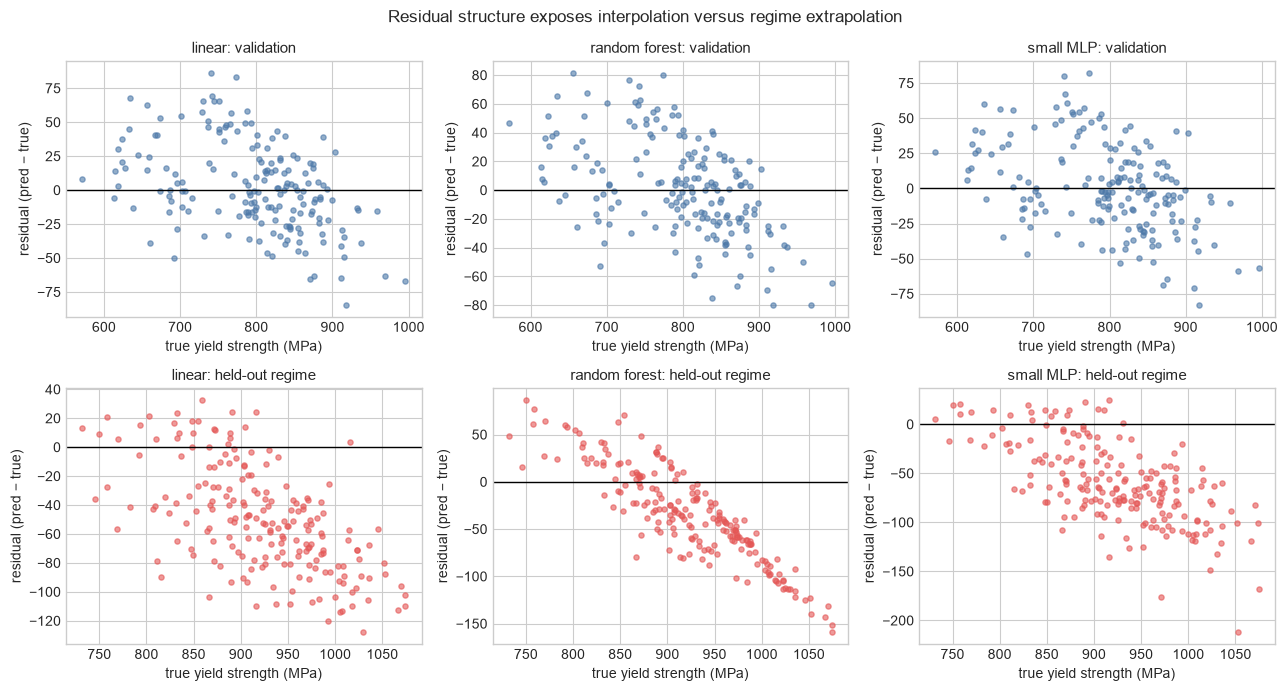

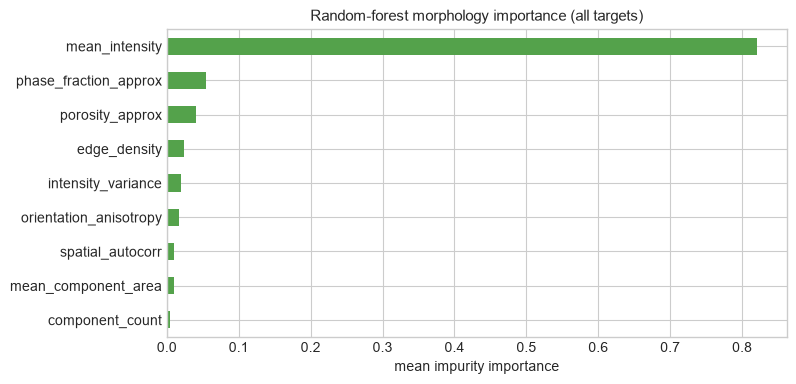

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for col, (name, predictor) in enumerate(property_predictions.items()):
    for row, (split_name, idx, colour) in enumerate([
        ("validation", val_idx, "#4C78A8"), ("held-out regime", ood_idx, "#E45756")
    ]):
        pred = predictor(X[idx])[:, 0]
        truth = y[idx, 0]
        axes[row, col].scatter(truth, pred - truth, s=14, alpha=.6, color=colour)
        axes[row, col].axhline(0, color="black", lw=1)
        axes[row, col].set_title(f"{name}: {split_name}")
        axes[row, col].set_xlabel("true yield strength (MPa)")
        axes[row, col].set_ylabel("residual (pred − true)")
plt.suptitle("Residual structure exposes interpolation versus regime extrapolation")
plt.tight_layout(); plt.show()

importance = pd.Series(forest_model.feature_importances_, index=MORPH_NAMES).sort_values()
importance.plot.barh(color="#54A24B", title="Random-forest morphology importance (all targets)")
plt.xlabel("mean impurity importance"); plt.show()

**Reading the result.** Validation samples share the development regimes, so this mostly
tests interpolation. The red held-out regime requires extrapolation. A feature can carry
genuine signal in the simulator yet still become spuriously predictive if regime and
magnification, preparation, or instrument artefacts are entangled. Grouped splits stop
near-duplicate images of one physical batch leaking across the boundary.

<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** Compare train, validation, and red held-out residuals—not just one
headline $R^2$. A systematic red slope means the model is smoothing the new regime back
toward familiar targets. Feature importance describes the fitted forest, not a causal law.

**Common trap.** Repeated fields of view from one specimen are not independent samples.
Random image splitting would let the model recognise specimens and report an inflated
score. This is exactly why the repository's adapters expose `group_id`.

**Guided exercise.** Replace the grouped validation split with a random image split only
long enough to observe the inflation, then restore it. Explain what information leaked
before looking at the score.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> Explicit image statistics recover part of the known process–structure–property signal.<br>
<b>What did it fail to learn?</b> They discard spatial arrangements and extrapolate poorly when the feature/property relation shifts.<br>
<b>What would falsify our interpretation?</b> If shuffled properties or outside-blanket artefacts perform equally well under grouped splits, the claimed structural signal is false.<br>
<b>What should I try next?</b> Remove one morphology feature, or hold out a different regime, and predict which target suffers most.
</div>

## Part 2 — Bayesian inference and Helmholtz-style inference

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** Bayesian inversion has three moves: state what structures were
plausible before this image (prior), predict what observations each structure tends to
produce (likelihood), and renormalise their product (posterior). The result is a
distribution, not merely a best guess.

**Follow the code.** Grain size and phase fraction form a 2-D hypothesis grid. Two
calibrated morphology statistics supply the likelihood. The red cross is visible only
because synthetic ground truth lets us check whether posterior mass covers the truth.

**Pause and predict.** Increasing observation noise should broaden the posterior and pull
it toward the prior. Adding an informative statistic should contract it, but only if the
observation model for that statistic is correctly specified.

In [10]:
explain_equation(
    r"p(\eta\mid s)=\frac{p(s\mid\eta)p(\eta)}{p(s)}",
    {r"\eta": "hidden material state (grain size, phase fraction)", "s": "observed SEM statistics", "p(η)": "prior", "p(s|η)": "likelihood", "p(η|s)": "posterior"},
    {r"\eta": "grid [G,P,2]", "s": "[2]", "p(η|s)": "[G,P]"},
    random="η before observation and the noisy statistics s.",
    fixed="The chosen image statistics once measured.",
    optimised="Nothing here; Bayes' rule updates a distribution by normalisation.",
    materials_analogy="Reverse the generative direction: infer plausible hidden structure from an SEM observation."
)

### Equation lens

$$ p(\eta\mid s)=\frac{p(s\mid\eta)p(\eta)}{p(s)} $$

- **$\eta$** — hidden material state (grain size, phase fraction); shape `grid [G,P,2]`
- **$s$** — observed SEM statistics; shape `[2]`
- **$p(η)$** — prior; shape `scalar`
- **$p(s|η)$** — likelihood; shape `scalar`
- **$p(η|s)$** — posterior; shape `[G,P]`

- **Random:** η before observation and the noisy statistics s.
- **Fixed/observed:** The chosen image statistics once measured.
- **Optimised:** Nothing here; Bayes' rule updates a distribution by normalisation.
- **Materials interpretation:** Reverse the generative direction: infer plausible hidden structure from an SEM observation.

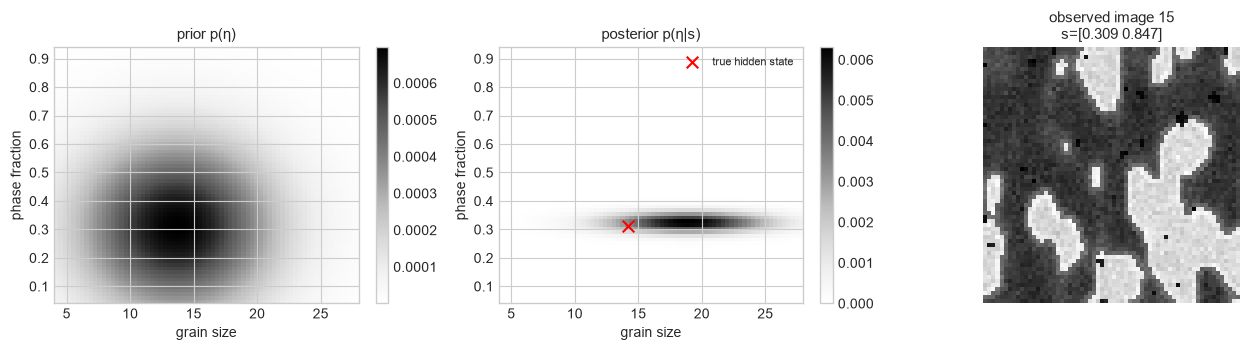

In [11]:
# Learn a deliberately simple observation model from development data.
phase_obs_model = LinearRegression().fit(
    synthetic.loc[train_idx, ["phase_fraction"]], feature_frame.loc[train_idx, "phase_fraction_approx"]
)
auto_obs_model = LinearRegression().fit(
    synthetic.loc[train_idx, ["grain_size"]], feature_frame.loc[train_idx, "spatial_autocorr"]
)
phase_sigma = max(0.025, np.std(
    phase_obs_model.predict(synthetic.loc[train_idx, ["phase_fraction"]])
    - feature_frame.loc[train_idx, "phase_fraction_approx"]
))
auto_sigma = max(0.015, np.std(
    auto_obs_model.predict(synthetic.loc[train_idx, ["grain_size"]])
    - feature_frame.loc[train_idx, "spatial_autocorr"]
))

grain_grid = np.linspace(4, 28, 70)
phase_grid = np.linspace(.04, .94, 70)
G, P = np.meshgrid(grain_grid, phase_grid, indexing="ij")
prior = np.exp(-0.5 * ((G - synthetic.loc[train_idx, "grain_size"].mean()) / 5.5) ** 2)
prior *= np.exp(-0.5 * ((P - synthetic.loc[train_idx, "phase_fraction"].mean()) / .22) ** 2)
prior /= prior.sum()

query_idx = int(val_idx[3])
observed_s = feature_frame.loc[query_idx, ["phase_fraction_approx", "spatial_autocorr"]].to_numpy()
mu_phase = phase_obs_model.intercept_ + phase_obs_model.coef_[0] * P
mu_auto = auto_obs_model.intercept_ + auto_obs_model.coef_[0] * G
log_likelihood = -0.5 * ((observed_s[0] - mu_phase) / phase_sigma) ** 2
log_likelihood += -0.5 * ((observed_s[1] - mu_auto) / auto_sigma) ** 2
likelihood = np.exp(log_likelihood - log_likelihood.max())
posterior = likelihood * prior
posterior /= posterior.sum()
assert np.isclose(posterior.sum(), 1.0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, density, title in zip(axes[:2], [prior, posterior], ["prior p(η)", "posterior p(η|s)"]):
    im = ax.imshow(density.T, origin="lower", aspect="auto",
                   extent=[grain_grid.min(), grain_grid.max(), phase_grid.min(), phase_grid.max()])
    ax.set(xlabel="grain size", ylabel="phase fraction", title=title)
    fig.colorbar(im, ax=ax, fraction=.045)
axes[1].scatter(synthetic.loc[query_idx, "grain_size"], synthetic.loc[query_idx, "phase_fraction"],
                marker="x", s=70, color="red", label="true hidden state")
axes[1].legend(fontsize=8)
axes[2].imshow(images[query_idx, 0], cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"observed image {query_idx}\ns={observed_s.round(3)}")
axes[2].axis("off")
plt.tight_layout(); plt.show()

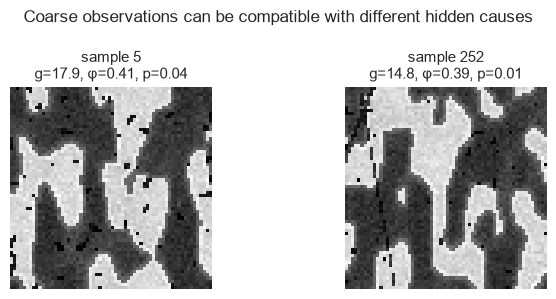

,grain_size,phase_fraction,porosity,mean_intensity,phase_fraction_approx,spatial_autocorr
5,17.945,0.407,0.038,0.481,0.389,0.783
252,14.810,0.393,0.013,0.482,0.380,0.785


In [12]:
# Find two samples that look alike in coarse statistics but have distant hidden states.
candidate = development_idx[:400]
coarse = StandardScaler().fit_transform(feature_frame.loc[candidate, [
    "mean_intensity", "phase_fraction_approx", "spatial_autocorr", "edge_density"
]])
hidden = StandardScaler().fit_transform(synthetic.loc[candidate, ["grain_size", "phase_fraction", "porosity"]])
d_image = pairwise_distances(coarse)
d_hidden = pairwise_distances(hidden)
np.fill_diagonal(d_image, np.inf)
score = d_image / (d_hidden + 1e-3)
i_local, j_local = np.unravel_index(np.argmin(score), score.shape)
ambiguous_pair = candidate[[i_local, j_local]]

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, idx in zip(axes, ambiguous_pair):
    ax.imshow(images[idx, 0], cmap="gray", vmin=0, vmax=1); ax.axis("off")
    ax.set_title(f"sample {idx}\ng={synthetic.loc[idx,'grain_size']:.1f}, φ={synthetic.loc[idx,'phase_fraction']:.2f}, p={synthetic.loc[idx,'porosity']:.2f}")
plt.suptitle("Coarse observations can be compatible with different hidden causes")
plt.tight_layout(); plt.show()
display(pd.concat([
    synthetic.loc[ambiguous_pair, ["grain_size", "phase_fraction", "porosity"]],
    feature_frame.loc[ambiguous_pair, ["mean_intensity", "phase_fraction_approx", "spatial_autocorr"]]
], axis=1).round(3))

This is *Helmholtz-style* analysis-by-synthesis: propose hidden causes, predict their
sensory consequences, and invert the model. It is a modelling perspective—not evidence
that this notebook or a metallurgist's brain literally implements this grid calculation.

<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** A narrow posterior can still be confidently wrong. Calibration
means that, over many samples, stated credible regions contain the true hidden state at
the promised frequency. The ambiguous-image pair shows why similar coarse evidence can
support distinct causes.

**Helmholtz connection.** The forward model predicts sensory consequences from causes;
inference runs that model backward by comparing predictions with evidence. This is an
analysis-by-synthesis idea, not a claim that the exact grid calculation occurs in a brain.

**Guided exercise.** Double `phase_sigma`, rerun the posterior, and explain separately
what happens to its phase marginal, grain marginal, and entropy.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> The posterior combines prior plausibility with image evidence and remains broad when the observation is ambiguous.<br>
<b>What did it fail to learn?</b> A two-statistic likelihood cannot identify every latent cause or capture multimodal real SEM noise.<br>
<b>What would falsify our interpretation?</b> Posterior credible regions that systematically miss known synthetic states would invalidate the observation model.<br>
<b>What should I try next?</b> Increase observation noise and watch evidence yield to the prior; then add edge density to the likelihood.
</div>

## Part 3 — Markov chains for heat-treatment trajectories

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** “Markov” does not mean the material has no history. It means the chosen
state contains enough history that earlier states add no predictive information. Whether
the assumption is reasonable depends on the state representation.

**Follow the code.** Each action selects a 5×5 row-stochastic transition matrix. Sampling
produces one possible trajectory; multiplying a belief vector by successive matrices
propagates all possible trajectories and their probabilities.

**Pause and predict.** Repeated quick cooling should accumulate probability in the
transformed state. Annealing should move mass toward fine/coarsened states, but damaged
and porous states are deliberately hard to escape.

In [13]:
explain_equation(
    r"p(z_{t+1}\mid z_t,z_{t-1},\ldots)=p(z_{t+1}\mid z_t)",
    {"z_t": "microstructure state at step t", "z_{t+1}": "next state"},
    {"z_t": "scalar state index or one-hot [5]", "P": "transition matrix [5,5]"},
    random="The next state sampled from a transition row.",
    fixed="Current state and selected processing action.",
    optimised="No parameters in this hand-built example.",
    materials_analogy="Given a sufficient current state, earlier thermal history adds no extra predictive information."
)

### Equation lens

$$ p(z_{t+1}\mid z_t,z_{t-1},\ldots)=p(z_{t+1}\mid z_t) $$

- **$z_t$** — microstructure state at step t; shape `scalar state index or one-hot [5]`
- **$z_{t+1}$** — next state; shape `scalar`

- **Random:** The next state sampled from a transition row.
- **Fixed/observed:** Current state and selected processing action.
- **Optimised:** No parameters in this hand-built example.
- **Materials interpretation:** Given a sufficient current state, earlier thermal history adds no extra predictive information.

In [14]:
STATE_NAMES = ["fine-grained", "coarsening", "transformed", "damaged", "porous"]
STATE_PROPERTIES = np.array([
    [760, 20], [610, 25], [900, 11], [480, 7], [390, 14]
])  # columns: yield strength, ductility

TRANSITIONS = {
    "heat": np.array([
        [.10,.62,.22,.04,.02], [.03,.65,.20,.09,.03], [.02,.38,.42,.13,.05],
        [.01,.16,.12,.66,.05], [.01,.13,.08,.10,.68],
    ]),
    "cool quickly": np.array([
        [.20,.05,.70,.03,.02], [.15,.08,.68,.06,.03], [.05,.02,.86,.05,.02],
        [.03,.03,.25,.66,.03], [.02,.03,.16,.08,.71],
    ]),
    "cool slowly": np.array([
        [.35,.42,.12,.06,.05], [.10,.68,.10,.07,.05], [.20,.45,.24,.07,.04],
        [.04,.15,.10,.66,.05], [.03,.14,.07,.09,.67],
    ]),
    "deform": np.array([
        [.48,.05,.18,.25,.04], [.28,.12,.18,.37,.05], [.18,.05,.35,.38,.04],
        [.04,.03,.07,.82,.04], [.03,.03,.05,.17,.72],
    ]),
    "anneal": np.array([
        [.68,.18,.09,.03,.02], [.42,.43,.08,.04,.03], [.33,.31,.27,.06,.03],
        [.18,.24,.12,.42,.04], [.08,.20,.08,.10,.54],
    ]),
}
for action, matrix in TRANSITIONS.items():
    assert matrix.shape == (5, 5) and np.allclose(matrix.sum(axis=1), 1), action

display(pd.DataFrame(TRANSITIONS["cool quickly"], index=STATE_NAMES, columns=STATE_NAMES).round(2))

def sample_process(initial: int, actions: list[str], seed: int = 0) -> list[int]:
    rng = np.random.default_rng(seed)
    states = [initial]
    for action in actions:
        states.append(rng.choice(5, p=TRANSITIONS[action][states[-1]]))
    return states

actions = ["heat", "cool quickly", "anneal", "deform", "anneal"]
path = sample_process(0, actions, CONFIG.seed)
pd.DataFrame({"step": range(len(path)), "action_into_state": ["start"] + actions,
              "state": np.array(STATE_NAMES)[path]})

,fine-grained,coarsening,transformed,damaged,porous
fine-grained,0.20,0.05,0.70,0.03,0.02
coarsening,0.15,0.08,0.68,0.06,0.03
transformed,0.05,0.02,0.86,0.05,0.02
damaged,0.03,0.03,0.25,0.66,0.03
porous,0.02,0.03,0.16,0.08,0.71


,step,action_into_state,state
0,0,start,fine-grained
1,1,heat,transformed
2,2,cool quickly,transformed
3,3,anneal,coarsening
4,4,deform,coarsening
5,5,anneal,fine-grained


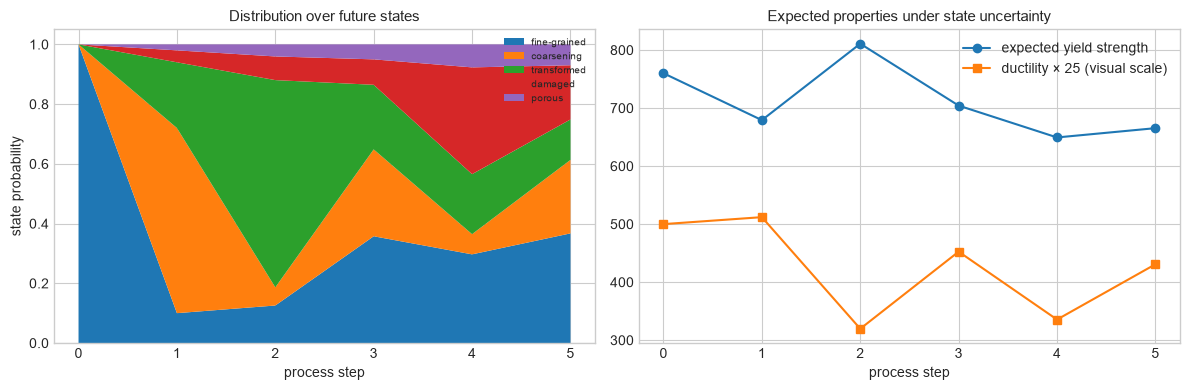

In [15]:
belief = np.array([1, 0, 0, 0, 0.], dtype=float)
belief_history = [belief.copy()]
for action in actions:
    belief = belief @ TRANSITIONS[action]
    belief_history.append(belief.copy())
belief_history = np.stack(belief_history)
expected_properties = belief_history @ STATE_PROPERTIES

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stackplot(range(len(belief_history)), belief_history.T, labels=STATE_NAMES)
axes[0].set(xlabel="process step", ylabel="state probability", title="Distribution over future states")
axes[0].legend(fontsize=7, loc="upper right")
axes[1].plot(expected_properties[:, 0], marker="o", label="expected yield strength")
axes[1].plot(expected_properties[:, 1] * 25, marker="s", label="ductility × 25 (visual scale)")
axes[1].set(xlabel="process step", title="Expected properties under state uncertainty")
axes[1].legend(); plt.tight_layout(); plt.show()

In [16]:
# Violation: damage risk depends on accumulated thermal exposure, not just state label.
def damage_probability(state: int, accumulated_heat: float) -> float:
    base = np.array([.02, .05, .04, .30, .10])[state]
    return float(np.clip(base + .012 * accumulated_heat, 0, .95))

violation = pd.DataFrame({
    "same_current_state": ["coarsening"] * 4,
    "accumulated_heat": [0, 5, 15, 30],
})
violation["p(damage next)"] = [damage_probability(1, h) for h in violation.accumulated_heat]
display(violation)
print("Repair: expand z_t from [microstructure class] to [class, accumulated exposure bin].")
print("The enlarged state is closer to sufficient, so the process becomes approximately Markov again.")

,same_current_state,accumulated_heat,p(damage next)
0,coarsening,0,0.05
1,coarsening,5,0.11
2,coarsening,15,0.23
3,coarsening,30,0.41


Repair: expand z_t from [microstructure class] to [class, accumulated exposure bin].
The enlarged state is closer to sufficient, so the process becomes approximately Markov again.


<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** A sampled path is an anecdote; the stacked probability plot is the
model's full forecast. Expected property curves average over that uncertainty and may
describe no single realised sample.

**Why the violation matters.** Two specimens labelled “coarsening” can have different
damage risk if one has far greater thermal exposure. Adding exposure to the state is a
state-design repair, not a trick.

**Guided exercise.** Simulate many paths from the same initial state, estimate the
empirical state distribution at step five, and compare it with matrix multiplication.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> Transition matrices propagate uncertainty over future microstructures and properties.<br>
<b>What did it fail to learn?</b> A coarse state label forgets thermal exposure, composition, and continuous kinetics.<br>
<b>What would falsify our interpretation?</b> If next-state frequencies vary with earlier history after conditioning on z_t, the Markov state is insufficient.<br>
<b>What should I try next?</b> Estimate a transition matrix from synthetic trajectories, then test whether exposure still predicts residual transitions.
</div>

## Part 4 — Markov blankets as local information boundaries

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** A Markov blanket is the smallest local set that makes a graph node
conditionally independent of more distant nodes. In a DAG it contains parents, children,
and the other parents of those children.

**Follow the code.** The graph is constructed to match the synthetic equations, including
direct temperature/cooling effects. The comparison uses the full blanket for statistical
demonstration, then asks whether distant composition/image proxies add much.

**Pause and predict.** Outside variables can predict yield marginally because they are
correlated with its causes. After conditioning on a correctly specified blanket their
incremental value should be small, though finite samples and model error prevent exact zero.

For a node in a directed acyclic graph, its Markov blanket is its parents, children,
and the other parents of its children. Conditioning on that set blocks information from
more distant nodes—if the graph and variables are correctly specified.

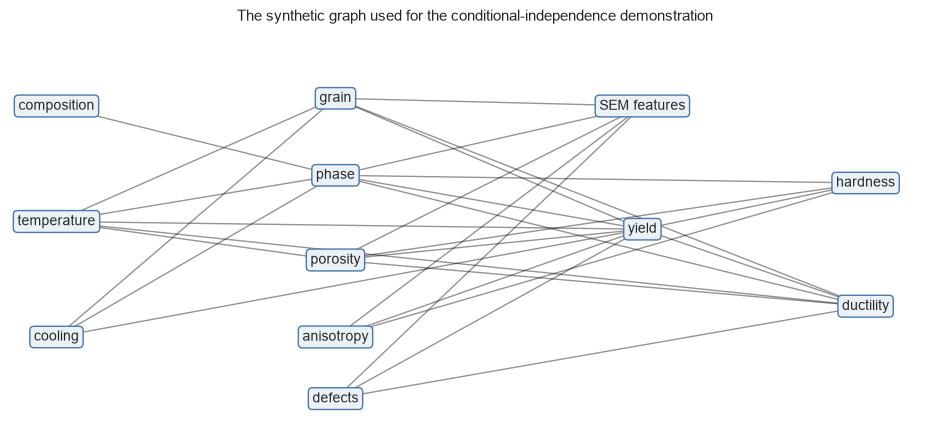

,target,Markov blanket
0,yield,"grain, phase, porosity, anisotropy, defects, t..."
1,hardness,"yield, phase, porosity, anisotropy"
2,SEM features,"grain, phase, porosity, anisotropy, defects"


In [17]:
graph_edges = [
    ("composition", "phase"), ("temperature", "grain"), ("temperature", "phase"),
    ("temperature", "porosity"), ("cooling", "grain"), ("cooling", "phase"),
    ("phase", "SEM features"), ("grain", "SEM features"), ("porosity", "SEM features"),
    ("anisotropy", "SEM features"), ("defects", "SEM features"),
    ("grain", "yield"), ("phase", "yield"), ("porosity", "yield"),
    ("anisotropy", "yield"), ("defects", "yield"), ("temperature", "yield"),
    ("cooling", "yield"),
    ("yield", "hardness"), ("phase", "hardness"), ("porosity", "hardness"),
    ("anisotropy", "hardness"),
    ("yield", "ductility"), ("grain", "ductility"), ("porosity", "ductility"),
    ("defects", "ductility"), ("phase", "ductility"), ("temperature", "ductility"),
]
positions = {
    "composition": (.05,.8), "temperature": (.05,.5), "cooling": (.05,.2),
    "grain": (.35,.82), "phase": (.35,.62), "porosity": (.35,.40),
    "anisotropy": (.35,.20), "defects": (.35,.04), "SEM features": (.68,.80),
    "yield": (.68,.48), "hardness": (.92,.60), "ductility": (.92,.28),
}
fig, ax = plt.subplots(figsize=(12, 5))
for a, b in graph_edges:
    ax.annotate("", positions[b], positions[a], arrowprops=dict(arrowstyle="->", alpha=.42))
for node, (x0, y0) in positions.items():
    ax.text(x0, y0, node, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=.3", fc="#eaf2f8", ec="#4C78A8"))
ax.axis("off"); ax.set_title("The synthetic graph used for the conditional-independence demonstration")
plt.show()

blankets = {
    "yield": ["grain", "phase", "porosity", "anisotropy", "defects", "temperature", "cooling", "hardness", "ductility"],
    "hardness": ["yield", "phase", "porosity", "anisotropy"],
    "SEM features": ["grain", "phase", "porosity", "anisotropy", "defects"],
}
pd.DataFrame({"target": blankets.keys(), "Markov blanket": [", ".join(v) for v in blankets.values()]})

In [18]:
causal_frame = pd.concat([synthetic.reset_index(drop=True), feature_frame.add_prefix("sem_")], axis=1)
mb_columns = [
    "grain_size", "phase_fraction", "porosity", "anisotropy", "defect_density",
    "processing_temperature", "cooling_rate", "hardness", "ductility",
]
outside_columns = ["composition"] + [f"sem_{c}" for c in MORPH_NAMES]
comparison_sets = {
    "only full Markov blanket": mb_columns,
    "blanket + distant variables": mb_columns + outside_columns,
    "outside blanket only": outside_columns,
}
blanket_rows = []
for name, columns in comparison_sets.items():
    model = RandomForestRegressor(n_estimators=80, min_samples_leaf=4,
                                  random_state=CONFIG.seed, n_jobs=-1)
    model.fit(causal_frame.loc[train_idx, columns], causal_frame.loc[train_idx, "yield_strength"])
    for split, idx in [("validation", val_idx), ("held-out regime", ood_idx)]:
        pred = model.predict(causal_frame.loc[idx, columns])
        blanket_rows.append({"variables": name, "split": split,
                             "R2": r2_score(causal_frame.loc[idx, "yield_strength"], pred),
                             "MAE": mean_absolute_error(causal_frame.loc[idx, "yield_strength"], pred)})
blanket_scores = pd.DataFrame(blanket_rows)
display(blanket_scores.round(3))

,variables,split,R2,MAE
0,only full Markov blanket,validation,0.913,18.791
1,only full Markov blanket,held-out regime,0.469,41.210
2,blanket + distant variables,validation,0.921,17.795
3,blanket + distant variables,held-out regime,0.531,38.564
4,outside blanket only,validation,0.838,26.774
5,outside blanket only,held-out regime,0.352,46.188


Distant variables can still predict yield strength marginally because causes propagate
correlation through the graph. The blanket claim is conditional: once sufficient direct
structural causes are known, distant processing/image variables should add little.

This statistical demonstration includes hardness and ductility because they are children
of yield and therefore belong to its full blanket. A deployable forward model should not
use downstream properties that are unavailable at prediction time; Part 1 uses only
upstream image morphology.

This is a **statistical information boundary**, not a literal membrane around a grain or
specimen. Active-inference literature often studies dynamical blankets; that stronger
interpretation requires a dynamical system, not just this DAG.

<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** “Outside-only” performance does not disprove the blanket; it shows
correlation through open causal paths. The relevant comparison is blanket versus blanket
plus distant variables.

**Prediction versus explanation.** Hardness and ductility are children of yield and thus
belong to its statistical blanket, but using them to predict yield would be operationally
backward when those tests have not yet been performed. The Part 1 forward model therefore
uses upstream image features only.

**Guided exercise.** Omit porosity from the blanket and observe which distant proxy gains
importance. This mimics an unmeasured confounder or insufficient state variable.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> A compact local variable set nearly saturates prediction in the known synthetic graph.<br>
<b>What did it fail to learn?</b> Finite samples, noisy measurements, omitted causes, or a wrong graph can make distant variables appear useful.<br>
<b>What would falsify our interpretation?</b> A reproducible gain from distant variables after conditioning on correctly measured blanket variables falsifies the proposed blanket.<br>
<b>What should I try next?</b> Hide porosity from the blanket and see which outside proxy becomes useful.
</div>

## Part 5 — Representation learning

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** An autoencoder learns what is useful for reconstruction under its
bottleneck and loss—not what is automatically physical. A latent coordinate becomes
scientifically meaningful only through downstream tests.

**Follow the code.** Convolutions compress 64×64 pixels into ten numbers; the decoder
reconstructs pixels. PCA is only a 2-D viewing tool. Linear probes test property signal,
nearest neighbours test local geometry, and the corner-marker experiment tests sensitivity
to an irrelevant artefact.

**Pause and predict.** Phase fraction and brightness should dominate a short MSE-trained
autoencoder. Fine defects will blur. OOD samples should lie farther from training codes,
but distance alone will not guarantee reliable OOD detection.

A convolutional autoencoder compresses pixels without receiving property labels. We then
ask whether its latent geometry aligns with physical variables, supports retrieval, and
notices the held-out regime. Reconstruction alone does not guarantee physical meaning.

In [19]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim: int = 10):
        super().__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 8, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(8, 16, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(16, 32, 4, 2, 1), nn.SiLU(),
        )
        self.to_latent = nn.Linear(32 * 8 * 8, latent_dim)
        self.from_latent = nn.Linear(latent_dim, 32 * 8 * 8)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.SiLU(),
            nn.ConvTranspose2d(16, 8, 4, 2, 1), nn.SiLU(),
            nn.ConvTranspose2d(8, 1, 4, 2, 1), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        return self.to_latent(h.flatten(1))

    def decode(self, z):
        h = self.from_latent(z).view(-1, 32, 8, 8)
        return self.decoder_conv(h)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

image_tensor = torch.tensor(images, dtype=torch.float32)
ae = ConvAutoencoder().to(DEVICE)
ae_opt = torch.optim.Adam(ae.parameters(), lr=2e-3)
ae_loader = DataLoader(TensorDataset(image_tensor[train_idx]), batch_size=CONFIG.batch_size, shuffle=True)
ae_history = []
for epoch in range(CONFIG.epochs):
    ae.train(); running = 0.0
    for (xb,) in ae_loader:
        xb = xb.to(DEVICE)
        ae_opt.zero_grad(); reconstruction, z = ae(xb)
        loss = F.mse_loss(reconstruction, xb)
        loss.backward(); ae_opt.step()
        running += loss.item() * len(xb)
    ae_history.append(running / len(train_idx))
with torch.no_grad():
    sample_recon, sample_z = ae(image_tensor[:4].to(DEVICE))
print("autoencoder shapes:", tuple(image_tensor[:4].shape), "→", tuple(sample_z.shape), "→", tuple(sample_recon.shape))
print("epoch reconstruction MSE:", np.round(ae_history, 5))

autoencoder shapes: (4, 1, 64, 64) → (4, 10) → (4, 1, 64, 64)
epoch reconstruction MSE: [0.08979 0.08658 0.08563 0.08457 0.08257 0.07932 0.07449 0.07167 0.07014
 0.06963]


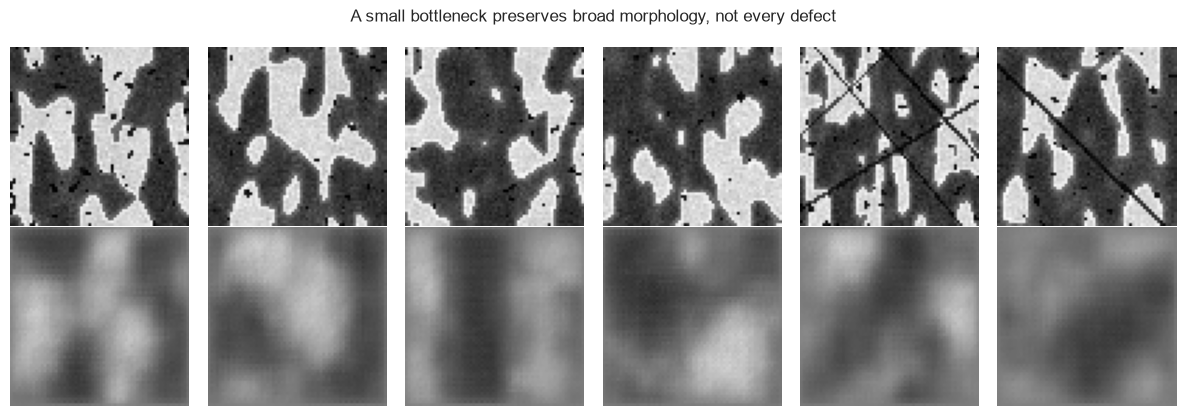

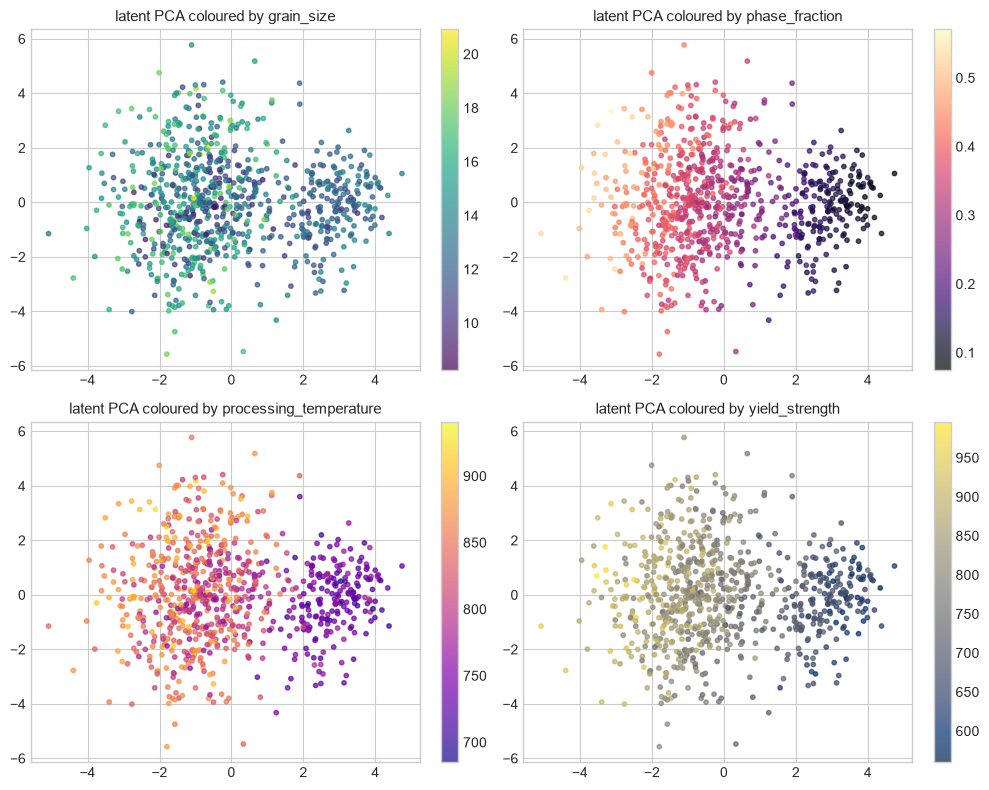

In [20]:
ae.eval()
with torch.no_grad():
    embedding = ae.encode(image_tensor.to(DEVICE)).cpu().numpy()
    recon_examples = ae(image_tensor[val_idx[:6]].to(DEVICE))[0].cpu().numpy()

fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
for col, idx in enumerate(val_idx[:6]):
    axes[0, col].imshow(images[idx, 0], cmap="gray", vmin=0, vmax=1); axes[0, col].axis("off")
    axes[1, col].imshow(recon_examples[col, 0], cmap="gray", vmin=0, vmax=1); axes[1, col].axis("off")
axes[0, 0].set_ylabel("input"); axes[1, 0].set_ylabel("reconstruction")
plt.suptitle("A small bottleneck preserves broad morphology, not every defect")
plt.tight_layout(); plt.show()

pca = PCA(n_components=2, random_state=CONFIG.seed)
embedding_2d = pca.fit_transform(embedding[train_idx].tolist() + embedding[val_idx].tolist())
plot_idx = np.concatenate([train_idx, val_idx])
colour_specs = [
    ("grain_size", "viridis"), ("phase_fraction", "magma"),
    ("processing_temperature", "plasma"), ("yield_strength", "cividis"),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (column, cmap) in zip(axes.ravel(), colour_specs):
    scatter = ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
                         c=synthetic.loc[plot_idx, column], cmap=cmap, s=10, alpha=.7)
    ax.set_title(f"latent PCA coloured by {column}")
    fig.colorbar(scatter, ax=ax, fraction=.045)
plt.tight_layout(); plt.show()

,split,R2 yield_strength,R2 hardness,R2 ductility
0,validation,0.771,0.810,0.550
1,held-out regime,0.635,0.362,0.136


nearest-train latent distance: validation median=2.792; OOD median=3.278


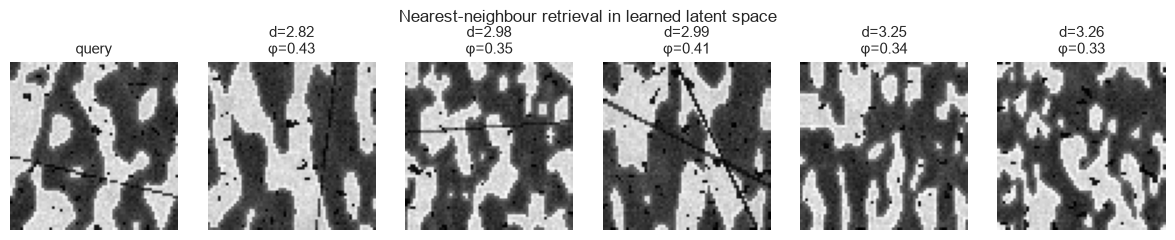

In [21]:
# Does the unsupervised code carry property signal, and does distance flag OOD samples?
latent_property = LinearRegression().fit(embedding[train_idx], y[train_idx])
latent_rows = []
for split, idx in [("validation", val_idx), ("held-out regime", ood_idx)]:
    pred = latent_property.predict(embedding[idx])
    latent_rows.append({"split": split, **{
        f"R2 {target}": r2_score(y[idx, j], pred[:, j]) for j, target in enumerate(TARGET_NAMES)
    }})
display(pd.DataFrame(latent_rows).round(3))

neighbour_model = NearestNeighbors(n_neighbors=1).fit(embedding[train_idx])
val_distance = neighbour_model.kneighbors(embedding[val_idx])[0].ravel()
ood_distance = neighbour_model.kneighbors(embedding[ood_idx])[0].ravel()
print(f"nearest-train latent distance: validation median={np.median(val_distance):.3f}; OOD median={np.median(ood_distance):.3f}")

query = int(val_idx[8])
retrieval = NearestNeighbors(n_neighbors=5).fit(embedding[train_idx])
distances, neighbour_positions = retrieval.kneighbors(embedding[[query]])
neighbours = train_idx[neighbour_positions[0]]
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
axes[0].imshow(images[query, 0], cmap="gray"); axes[0].set_title("query"); axes[0].axis("off")
for ax, idx, distance in zip(axes[1:], neighbours, distances[0]):
    ax.imshow(images[idx, 0], cmap="gray"); ax.axis("off"); ax.set_title(f"d={distance:.2f}\nφ={synthetic.loc[idx,'phase_fraction']:.2f}")
plt.suptitle("Nearest-neighbour retrieval in learned latent space"); plt.tight_layout(); plt.show()

,perturbation,median latent shift
0,small sensor noise,0.056
1,irrelevant corner marker,0.764


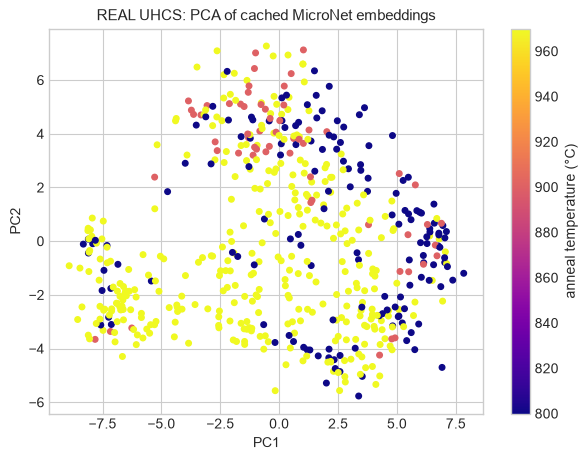

In [22]:
# Artefact probe: a bright corner marker should not represent material state, but it moves the code.
probe_idx = val_idx[:60]
clean_probe = image_tensor[probe_idx].clone()
marked_probe = clean_probe.clone(); marked_probe[:, :, :8, :8] = 1.0
noisy_probe = torch.clamp(clean_probe + 0.03 * torch.randn_like(clean_probe), 0, 1)
with torch.no_grad():
    z_clean = ae.encode(clean_probe.to(DEVICE)).cpu().numpy()
    z_marked = ae.encode(marked_probe.to(DEVICE)).cpu().numpy()
    z_noisy = ae.encode(noisy_probe.to(DEVICE)).cpu().numpy()
shifts = pd.DataFrame({
    "perturbation": ["small sensor noise", "irrelevant corner marker"],
    "median latent shift": [
        np.median(np.linalg.norm(z_noisy-z_clean, axis=1)),
        np.median(np.linalg.norm(z_marked-z_clean, axis=1)),
    ]
})
display(shifts.round(3))

# Reuse the repo's microscopy-pretrained representation rather than retraining it here.
real_embedding_path = PROJECT_ROOT / "data" / "temperature_probe_features.npz"
if real_embedding_path.exists():
    real_npz = np.load(real_embedding_path)
    real_embedding = real_npz["features"]
    real_ids = real_npz["ids"]
    real_join = pd.DataFrame({"micrograph_id": real_ids}).merge(real_meta, on="micrograph_id", how="left")
    real_pca = PCA(n_components=2, random_state=CONFIG.seed).fit_transform(real_embedding)
    temperatures = pd.to_numeric(real_join.anneal_temperature, errors="coerce")
    valid = temperatures.notna().to_numpy()
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(real_pca[valid, 0], real_pca[valid, 1], c=temperatures[valid], cmap="plasma", s=16)
    plt.colorbar(sc, label="anneal temperature (°C)")
    plt.title("REAL UHCS: PCA of cached MicroNet embeddings")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** Smooth colour gradients in PCA are stronger evidence than visually
pleasing clusters, but still not proof of causal disentanglement. Retrieval is often the
best qualitative audit: ask whether neighbours agree in morphology for the right reason.

**Repository connection.** The real-data plot uses cached MicroNet features from 553 UHCS
images. Those microscopy-pretrained representations are more credible for real transfer
than the tiny synthetic autoencoder, while still requiring grouped evaluation.

**Guided exercise.** Add random brightness shifts during training. A useful invariant
representation should reduce the marker/brightness shift without erasing phase morphology.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> The autoencoder organises images by reconstructible visual factors, some of which align with physical latents.<br>
<b>What did it fail to learn?</b> It has no reason to ignore acquisition artefacts or preserve rare defects and property-relevant extremes.<br>
<b>What would falsify our interpretation?</b> If latent neighbours match only brightness or markers while disagreeing physically, the representation claim is falsified.<br>
<b>What should I try next?</b> Add a contrastive augmentation that changes brightness but preserves morphology, then rerun retrieval.
</div>

## Part 6 — Predictive coding through iterative latent-state inference

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** An encoder makes one fast bottom-up guess. Predictive-coding inference
freezes the generative weights and treats the latent state itself as the variable to
optimise. Top-down predictions generate errors; precision decides which errors matter.

**Follow the code.** Five physical coordinates plus ten texture coordinates predict
morphology and pixels. The amortised encoder initialises belief. `iterative_state_inference`
then updates only `z`, recording the belief, reconstruction, and error trajectory.

**Pause and predict.** Lower pixel precision for noisy images should stop sensor noise
from pulling beliefs too far. A mask with zero precision should be filled by prior/model
expectations rather than treated as observed grey pixels.

This section does not merely rename the autoencoder. It trains an explicit top-down
generator `latent state → predicted morphology → predicted pixels`. At inference time
the weights are frozen and latent beliefs themselves are updated to reduce weighted
prediction errors plus a prior cost.

In [23]:
explain_equation(
    r"F(z)=\frac{\pi_x}{2}\lVert x-g_\theta(z)\rVert^2+\frac{\pi_s}{2}\lVert s-h_\theta(z)\rVert^2+\frac{\pi_z}{2}\lVert z\rVert^2",
    {"z": "latent belief: 5 physical coordinates plus 10 texture coordinates", "x": "observed pixels", "s": "observed morphology", r"g_\theta": "pixel prediction", r"h_\theta": "morphology prediction", r"\pi": "precision weights"},
    {"z": "[batch,15]", "s": "[batch,9]", "x": "[batch,1,64,64]"},
    random="Noisy pixels/morphology and uncertain latent state.",
    fixed="Trained generator parameters θ during inference.",
    optimised="Latent belief z by gradient descent.",
    materials_analogy="Adjust a hypothesised grain/phase/pore state until it explains both SEM pixels and measured morphology."
)

### Equation lens

$$ F(z)=\frac{\pi_x}{2}\lVert x-g_\theta(z)\rVert^2+\frac{\pi_s}{2}\lVert s-h_\theta(z)\rVert^2+\frac{\pi_z}{2}\lVert z\rVert^2 $$

- **$z$** — latent belief: 5 physical coordinates plus 10 texture coordinates; shape `[batch,15]`
- **$x$** — observed pixels; shape `[batch,1,64,64]`
- **$s$** — observed morphology; shape `[batch,9]`
- **$g_\theta$** — pixel prediction; shape `scalar`
- **$h_\theta$** — morphology prediction; shape `scalar`
- **$\pi$** — precision weights; shape `scalar`

- **Random:** Noisy pixels/morphology and uncertain latent state.
- **Fixed/observed:** Trained generator parameters θ during inference.
- **Optimised:** Latent belief z by gradient descent.
- **Materials interpretation:** Adjust a hypothesised grain/phase/pore state until it explains both SEM pixels and measured morphology.

In [24]:
PC_PHYSICAL_LATENTS = ["grain_size", "phase_fraction", "porosity", "anisotropy", "defect_density"]
pc_z_scaler = StandardScaler().fit(synthetic.loc[train_idx, PC_PHYSICAL_LATENTS])
pc_texture_scaler = StandardScaler().fit(embedding[train_idx])
pc_s_scaler = StandardScaler().fit(feature_frame.loc[train_idx, MORPH_NAMES])
z_all = np.column_stack([
    pc_z_scaler.transform(synthetic[PC_PHYSICAL_LATENTS]),
    pc_texture_scaler.transform(embedding),
]).astype(np.float32)
s_all = pc_s_scaler.transform(feature_frame[MORPH_NAMES]).astype(np.float32)

class HierarchicalGenerator(nn.Module):
    def __init__(self, z_dim=15, s_dim=9, size=64):
        super().__init__(); self.size = size
        self.morphology = nn.Sequential(nn.Linear(z_dim, 32), nn.Tanh(), nn.Linear(32, s_dim))
        self.pixel_seed = nn.Sequential(
            nn.Linear(z_dim + s_dim, 32 * 8 * 8), nn.SiLU(),
        )
        self.pixel_decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.SiLU(),
            nn.ConvTranspose2d(16, 8, 4, 2, 1), nn.SiLU(),
            nn.ConvTranspose2d(8, 1, 4, 2, 1), nn.Sigmoid(),
        )
    def forward(self, z):
        s_hat = self.morphology(z)
        seed = self.pixel_seed(torch.cat([z, s_hat], dim=1)).view(-1, 32, 8, 8)
        x_hat = self.pixel_decoder(seed)
        return s_hat, x_hat

class AmortisedStateEncoder(nn.Module):
    def __init__(self, z_dim=15):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 5, 2, 2), nn.SiLU(),
            nn.Conv2d(8, 16, 5, 2, 2), nn.SiLU(),
            nn.Conv2d(16, 24, 5, 2, 2), nn.SiLU(),
        )
        self.head = nn.Linear(24 * 8 * 8, z_dim)
    def forward(self, x):
        return self.head(self.conv(x).flatten(1))

pc_generator = HierarchicalGenerator(z_dim=z_all.shape[1], size=CONFIG.image_size).to(DEVICE)
pc_encoder = AmortisedStateEncoder(z_dim=z_all.shape[1]).to(DEVICE)
pc_opt = torch.optim.Adam(list(pc_generator.parameters()) + list(pc_encoder.parameters()), lr=2e-3)
pc_dataset = TensorDataset(
    image_tensor[train_idx], torch.tensor(z_all[train_idx]), torch.tensor(s_all[train_idx])
)
pc_loader = DataLoader(pc_dataset, batch_size=CONFIG.batch_size, shuffle=True)
for epoch in range(22 if CONFIG.fast_demo else 60):
    for xb, zb, sb in pc_loader:
        xb, zb, sb = xb.to(DEVICE), zb.to(DEVICE), sb.to(DEVICE)
        pc_opt.zero_grad()
        s_hat, x_hat = pc_generator(zb)
        z_hat = pc_encoder(xb)
        loss = F.mse_loss(x_hat, xb) + .15 * F.mse_loss(s_hat, sb) + .25 * F.mse_loss(z_hat, zb)
        loss.backward(); pc_opt.step()
with torch.no_grad():
    shape_z = pc_encoder(image_tensor[:3].to(DEVICE))
    shape_s, shape_x = pc_generator(shape_z)
print("bottom-up:", tuple(image_tensor[:3].shape), "→", tuple(shape_z.shape))
print("top-down:", tuple(shape_z.shape), "→", tuple(shape_s.shape), "→", tuple(shape_x.shape))

bottom-up: (3, 1, 64, 64) → (3, 15)
top-down: (3, 15) → (3, 9) → (3, 1, 64, 64)


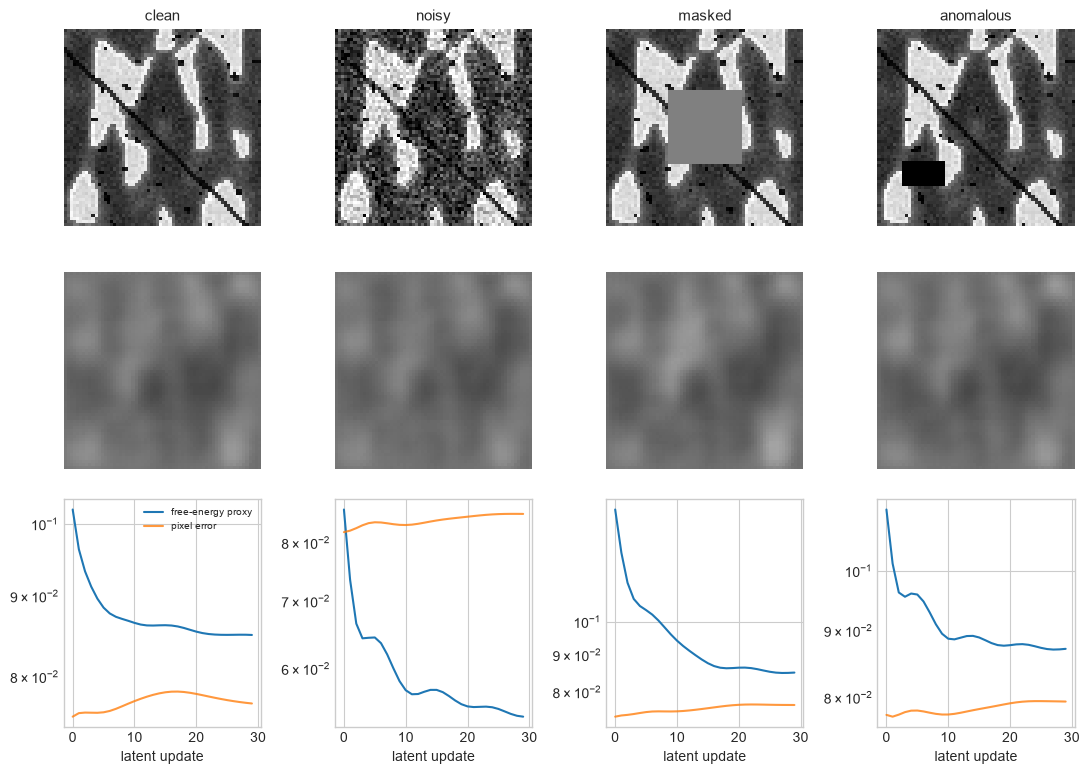

In [25]:
def iterative_state_inference(
    observation: torch.Tensor,
    initial_z: torch.Tensor,
    observed_morphology: torch.Tensor,
    *, steps: int = 30,
    pixel_precision: float = 1.0,
    morphology_precision: float = 0.15,
    prior_precision: float = 0.02,
    pixel_mask: torch.Tensor | None = None,
) -> dict[str, np.ndarray | torch.Tensor]:
    pc_generator.eval()
    z = nn.Parameter(initial_z.detach().clone())
    optimiser_z = torch.optim.Adam([z], lr=.08)
    mask = torch.ones_like(observation) if pixel_mask is None else pixel_mask
    history = {"total": [], "pixel": [], "morphology": [], "z": [], "reconstruction": []}
    for _ in range(steps):
        optimiser_z.zero_grad()
        s_hat, x_hat = pc_generator(z)
        pixel_error = ((x_hat - observation) ** 2 * mask).sum() / mask.sum().clamp_min(1)
        morphology_error = F.mse_loss(s_hat, observed_morphology)
        prior_error = torch.mean(z ** 2)
        total = pixel_precision * pixel_error + morphology_precision * morphology_error + prior_precision * prior_error
        total.backward(); optimiser_z.step()
        history["total"].append(float(total.detach()))
        history["pixel"].append(float(pixel_error.detach()))
        history["morphology"].append(float(morphology_error.detach()))
        history["z"].append(z.detach().cpu().numpy().copy())
        history["reconstruction"].append(x_hat.detach().cpu().numpy().copy())
    history["final_z"] = z.detach()
    return history

pc_cases = {}
base_idx = int(val_idx[5])
clean = image_tensor[[base_idx]].to(DEVICE)
noisy = torch.clamp(clean + .12 * torch.randn_like(clean), 0, 1)
masked = clean.clone(); mask = torch.ones_like(clean); mask[:, :, 20:44, 20:44] = 0; masked[mask == 0] = .5
anomalous = clean.clone(); anomalous[:, :, 43:51, 8:22] = 0
case_inputs = {"clean": (clean, None), "noisy": (noisy, None), "masked": (masked, mask), "anomalous": (anomalous, None)}
observed_s = torch.tensor(s_all[[base_idx]], dtype=torch.float32, device=DEVICE)
for name, (observation, weight_mask) in case_inputs.items():
    with torch.no_grad():
        initial = pc_encoder(observation)
    pc_cases[name] = iterative_state_inference(
        observation, initial, observed_s, steps=30,
        pixel_precision=.55 if name == "noisy" else 1.0,
        pixel_mask=weight_mask,
    )

fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for col, (name, (observation, _)) in enumerate(case_inputs.items()):
    axes[0, col].imshow(observation[0,0].cpu(), cmap="gray", vmin=0, vmax=1); axes[0,col].set_title(name)
    axes[1, col].imshow(pc_cases[name]["reconstruction"][-1][0,0], cmap="gray", vmin=0, vmax=1)
    axes[2, col].plot(pc_cases[name]["total"], label="free-energy proxy")
    axes[2, col].plot(np.array(pc_cases[name]["pixel"]), label="pixel error", alpha=.8)
    axes[2, col].set_xlabel("latent update"); axes[2, col].set_yscale("log")
    axes[0,col].axis("off"); axes[1,col].axis("off")
axes[0,0].set_ylabel("observation"); axes[1,0].set_ylabel("top-down prediction")
axes[2,0].legend(fontsize=7); plt.tight_layout(); plt.show()

In [26]:
compare_idx = val_idx[:40]
with torch.no_grad():
    amortised = pc_encoder(image_tensor[compare_idx].to(DEVICE))
inferred = []
for local, idx in enumerate(compare_idx):
    result = iterative_state_inference(
        image_tensor[[idx]].to(DEVICE), amortised[[local]],
        torch.tensor(s_all[[idx]], dtype=torch.float32, device=DEVICE), steps=12,
    )
    inferred.append(result["final_z"].cpu().numpy()[0])
inferred = np.stack(inferred)
true_z = z_all[compare_idx, :5]
comparison = pd.DataFrame({
    "inference": ["ordinary encoder (one pass)", "encoder + iterative prediction-error updates"],
    "physical-latent MSE": [
        np.mean((amortised.cpu().numpy()[:,:5]-true_z)**2),
        np.mean((inferred[:,:5]-true_z)**2),
    ],
})
display(comparison.round(4))
print("Precision weighting changes which discrepancies control the update.")
print("Calling attention 'precision control' is a modelling hypothesis: increasing a channel's precision makes its errors more influential.")

,inference,physical-latent MSE
0,ordinary encoder (one pass),0.6041
1,encoder + iterative prediction-error updates,0.3544


Precision weighting changes which discrepancies control the update.
Calling attention 'precision control' is a modelling hypothesis: increasing a channel's precision makes its errors more influential.


<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** Falling prediction error is necessary but not sufficient. The
physical-latent MSE checks whether the inferred explanation improves, rather than merely
finding a visually convenient code. Similar reconstructions across cases reveal the
limited capacity of this small top-down generator.

**Precision and attention.** Calling attention “precision control” means attended error
channels receive more influence in belief updates. It is a formal analogy/hypothesis, not
a synonym for every neural attention mechanism.

**Guided exercise.** Sweep noisy-image pixel precision over `[0.1, 0.5, 1, 5]` and plot
pixel fit against physical-latent error. Identify the overfitting region.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> Frozen top-down predictions can refine a fast bottom-up estimate through explicit latent updates.<br>
<b>What did it fail to learn?</b> The learned generator is blurry, and precision values were chosen rather than calibrated from repeated measurements.<br>
<b>What would falsify our interpretation?</b> If iterative updates reduce pixel error while moving known synthetic latents farther from truth, prediction-error minimisation is not identifying the right causes.<br>
<b>What should I try next?</b> Sweep pixel precision for the noisy image and plot the fit-versus-prior trade-off.
</div>

## Part 7 — Variational free energy

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** The VAE objective asks for two things at once: explain this image and
keep its approximate posterior compatible with a simple shared prior. Reconstruction is
accuracy; KL is complexity/mismatch.

**Follow the code.** The encoder outputs a mean and log-variance, the reparameterisation
trick creates a differentiable latent sample, and the decoder reconstructs the image.
`beta` controls the relative price of a specialised latent code.

**Pause and predict.** Very small beta allows idiosyncratic codes; very large beta makes
posteriors resemble the prior and can erase image information. If KL approaches zero while
reconstructions remain generic, suspect posterior collapse.

In [27]:
explain_equation(
    r"F=\mathbb{E}_{q_\phi(z\mid x)}[\log q_\phi(z\mid x)-\log p_\theta(x,z)]\approx \text{reconstruction}+\beta D_{KL}(q_\phi(z\mid x)\Vert p(z))",
    {"x": "SEM image", "z": "stochastic latent", r"q_\phi": "encoder distribution", r"p_\theta": "decoder/generative model", r"\beta": "complexity weight"},
    {"x": "[batch,1,64,64]", "z": "[batch,6]", "F": "scalar"},
    random="Latent sample z and observed image x.",
    fixed="A minibatch during one update and the standard-normal prior.",
    optimised="Encoder φ and decoder θ.",
    materials_analogy="Explain each SEM image while keeping its latent explanation inside a shared, plausible material-state space."
)

### Equation lens

$$ F=\mathbb{E}_{q_\phi(z\mid x)}[\log q_\phi(z\mid x)-\log p_\theta(x,z)]\approx \text{reconstruction}+\beta D_{KL}(q_\phi(z\mid x)\Vert p(z)) $$

- **$x$** — SEM image; shape `[batch,1,64,64]`
- **$z$** — stochastic latent; shape `[batch,6]`
- **$q_\phi$** — encoder distribution; shape `scalar`
- **$p_\theta$** — decoder/generative model; shape `scalar`
- **$\beta$** — complexity weight; shape `scalar`

- **Random:** Latent sample z and observed image x.
- **Fixed/observed:** A minibatch during one update and the standard-normal prior.
- **Optimised:** Encoder φ and decoder θ.
- **Materials interpretation:** Explain each SEM image while keeping its latent explanation inside a shared, plausible material-state space.

In [28]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=6):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(8, 16, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(16, 24, 4, 2, 1), nn.SiLU(),
        )
        self.mu = nn.Linear(24*8*8, latent_dim)
        self.logvar = nn.Linear(24*8*8, latent_dim)
        self.expand = nn.Linear(latent_dim, 24*8*8)
        self.decode_conv = nn.Sequential(
            nn.ConvTranspose2d(24, 16, 4, 2, 1), nn.SiLU(),
            nn.ConvTranspose2d(16, 8, 4, 2, 1), nn.SiLU(),
            nn.ConvTranspose2d(8, 1, 4, 2, 1), nn.Sigmoid(),
        )
    def encode(self, x):
        h = self.conv(x).flatten(1); return self.mu(h), self.logvar(h)
    def reparameterise(self, mu, logvar):
        return mu + torch.exp(.5*logvar) * torch.randn_like(mu)
    def decode(self, z):
        return self.decode_conv(self.expand(z).view(-1,24,8,8))
    def forward(self, x):
        mu, logvar = self.encode(x); z = self.reparameterise(mu, logvar)
        return self.decode(z), mu, logvar, z

def vae_terms(recon, x, mu, logvar):
    reconstruction = F.mse_loss(recon, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruction, kl

vae = ConvVAE().to(DEVICE)
vae_opt = torch.optim.Adam(vae.parameters(), lr=2e-3)
beta = .02
vae_history = []
for epoch in range(CONFIG.epochs):
    epoch_terms = []
    for (xb,) in ae_loader:
        xb = xb.to(DEVICE); vae_opt.zero_grad()
        recon, mu, logvar, z = vae(xb)
        reconstruction, kl = vae_terms(recon, xb, mu, logvar)
        total = reconstruction + beta * kl
        total.backward(); vae_opt.step()
        epoch_terms.append([reconstruction.item(), kl.item(), total.item()])
    vae_history.append(np.mean(epoch_terms, axis=0))
vae_history = pd.DataFrame(vae_history, columns=["reconstruction", "KL complexity", "total F"])
display(vae_history.round(5))
if vae_history["KL complexity"].iloc[-1] < 1e-3:
    print("Diagnosis: this short run is near posterior collapse—the decoder uses very little latent information.")
print("VAE shapes:", tuple(xb.shape), "→ μ/logvar", tuple(mu.shape), "→ z", tuple(z.shape), "→", tuple(recon.shape))

,reconstruction,KL complexity,total F
0,0.08565,0.00025,0.08565
1,0.08539,0.00003,0.08539
2,0.08548,0.00001,0.08548
3,0.08536,0.00001,0.08536
4,0.08537,0.00001,0.08537
5,0.08540,0.00001,0.08540
6,0.08534,0.00001,0.08534
7,0.08539,0.00001,0.08539
8,0.08540,0.00002,0.08540
9,0.08534,0.00006,0.08534


Diagnosis: this short run is near posterior collapse—the decoder uses very little latent information.
VAE shapes: (46, 1, 64, 64) → μ/logvar (46, 6) → z (46, 6) → (46, 1, 64, 64)


,β complexity weight,reconstruction,KL,total
0,0.0,0.08855,0.00012,0.08855
1,0.01,0.08855,0.00012,0.08855
2,0.02,0.08855,0.00012,0.08855
3,0.08,0.08855,0.00012,0.08856
4,1.0,0.08855,0.00012,0.08867
5,5.0,0.08855,0.00012,0.08914
6,0.02; pixel precision=0.5,0.04427,0.00012,0.04428
7,0.02; pixel precision=1.0,0.08855,0.00012,0.08855
8,0.02; pixel precision=4.0,0.35419,0.00012,0.35420


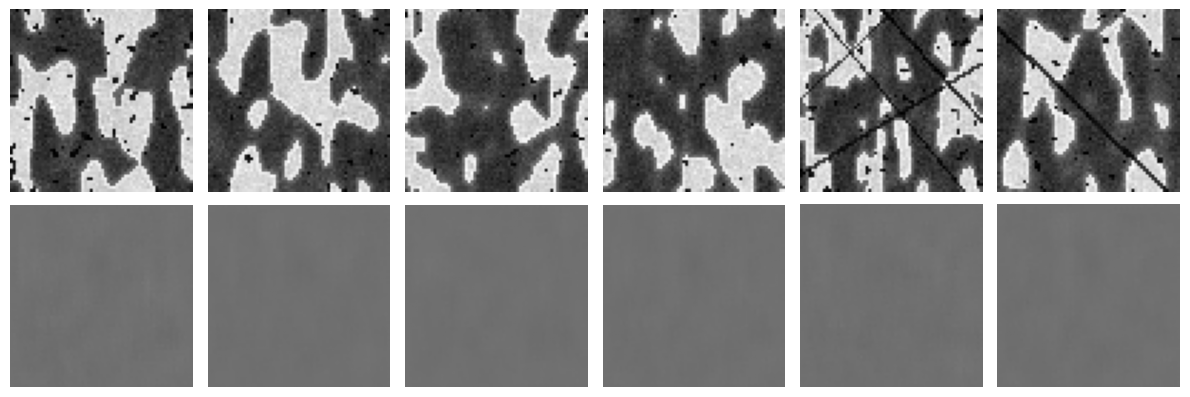

In [29]:
vae.eval()
batch = image_tensor[val_idx[:32]].to(DEVICE)
with torch.no_grad():
    recon, mu, logvar, z = vae(batch)
    reconstruction, kl = vae_terms(recon, batch, mu, logvar)
tradeoffs = []
for beta_test in [0.0, .01, .02, .08, 1.0, 5.0]:
    tradeoffs.append({"β complexity weight": beta_test,
                      "reconstruction": reconstruction.item(), "KL": kl.item(),
                      "total": reconstruction.item() + beta_test * kl.item()})
for precision in [.5, 1.0, 4.0]:
    tradeoffs.append({"β complexity weight": f"0.02; pixel precision={precision}",
                      "reconstruction": precision*reconstruction.item(), "KL": kl.item(),
                      "total": precision*reconstruction.item() + .02*kl.item()})
display(pd.DataFrame(tradeoffs).round(5))

fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
for col in range(6):
    axes[0,col].imshow(batch[col,0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[1,col].imshow(recon[col,0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[0,col].axis("off"); axes[1,col].axis("off")
axes[0,0].set_ylabel("image"); axes[1,0].set_ylabel("VAE sample")
plt.tight_layout(); plt.show()

With complexity weighted too weakly, latent codes can become idiosyncratic lookup keys.
Too strong a weight forces codes toward the prior and washes away image-specific detail
(posterior collapse is the extreme). Observation precision rescales the cost of failing
to explain pixels; it should come from a noise model, not aesthetic preference.

<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** This run explicitly diagnoses near posterior collapse. That is a
useful result: the decoder gains little from `z`, so sampling the prior cannot be expected
to recover diverse, physically organised structures.

**Important distinction.** Reweighting the displayed terms shows how the numerical
objective changes for fixed predictions. To learn the full behavioural effect, train
separate models at each beta and compare reconstruction, KL, samples, and property probes.

**Guided exercise.** Use KL warm-up—start beta at zero and increase it gradually. Track
whether nonzero KL survives without destroying reconstruction.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> The VAE trades image explanation against a shared, sampleable latent distribution.<br>
<b>What did it fail to learn?</b> A short CPU run does not establish disentanglement or calibrated likelihoods.<br>
<b>What would falsify our interpretation?</b> If samples from the prior are implausible or reconstructions ignore property-relevant defects, the chosen latent model fails its purpose.<br>
<b>What should I try next?</b> Train three β values fully and compare latent-property alignment, not just loss.
</div>

## Part 8 — Planning as inference and expected free energy

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** Planning as inference scores not only what an action is expected to
achieve, but what it is expected to teach. Extrinsic value concerns preferred outcomes;
state information gain concerns this specimen; model information gain concerns knowledge
useful across future specimens.

**Follow the code.** The notebook commits to one sign convention: minimise cost minus
value minus information gains. The numbers are transparent toy estimates so you can see
why policies disagree.

**Pause and predict.** Pure reward should manufacture immediately. Uncertainty sampling
should inspect. Expected free energy will inspect only while the weighted future value of
information exceeds the opportunity and experimental cost.

We adopt one explicit convention and minimise
$G(a)=\text{expected cost}-\text{extrinsic value}-\lambda_s\,\text{state information gain}-\lambda_m\,\text{model information gain}$.
Other texts move terms or change signs; always inspect the convention before comparing values.

In [30]:
explain_equation(
    r"G(a)=C(a)-V(a)-\lambda_s I(\eta;o\mid a)-\lambda_m I(\theta;o\mid a)",
    {"a": "processing or measurement action", "C": "experimental cost", "V": "preferred-outcome value", r"I(\eta;o|a)": "state uncertainty reduction (salience)", r"I(\theta;o|a)": "model/parameter information gain (novelty)"},
    {"a": "one of 6 discrete actions", "G": "scalar per action"},
    random="Future observation o, state η, and uncertain parameters θ.",
    fixed="Current beliefs, preferences, and information weights.",
    optimised="Choose the action with minimum G under this sign convention.",
    materials_analogy="Trade desired properties and experimental cost against learning what specimen and model you actually have."
)

### Equation lens

$$ G(a)=C(a)-V(a)-\lambda_s I(\eta;o\mid a)-\lambda_m I(\theta;o\mid a) $$

- **$a$** — processing or measurement action; shape `one of 6 discrete actions`
- **$C$** — experimental cost; shape `scalar`
- **$V$** — preferred-outcome value; shape `scalar`
- **$I(\eta;o|a)$** — state uncertainty reduction (salience); shape `scalar`
- **$I(\theta;o|a)$** — model/parameter information gain (novelty); shape `scalar`

- **Random:** Future observation o, state η, and uncertain parameters θ.
- **Fixed/observed:** Current beliefs, preferences, and information weights.
- **Optimised:** Choose the action with minimum G under this sign convention.
- **Materials interpretation:** Trade desired properties and experimental cost against learning what specimen and model you actually have.

In [31]:
action_table = pd.DataFrame({
    "action": [
        "increase annealing temperature", "increase cooling rate", "inspect another SEM region",
        "perform another hardness test", "stop experimenting", "manufacture sample",
    ],
    "expected reward": [6.5, 7.2, 2.0, 2.4, 4.0, 10.0],
    "experimental cost": [2.4, 2.1, 1.0, 1.8, 0.0, 0.8],
    "state information gain": [.35, .30, 4.0, 2.4, 0.0, 0.0],
    "model information gain": [.25, .40, 3.0, 3.8, 0.0, 0.0],
})
lambda_state, lambda_model = 1.8, 1.2
action_table["expected free energy"] = (
    action_table["experimental cost"] - action_table["expected reward"]
    - lambda_state * action_table["state information gain"]
    - lambda_model * action_table["model information gain"]
)
action_table["pure reward rank"] = action_table["expected reward"].rank(ascending=False).astype(int)
action_table["uncertainty rank"] = action_table["state information gain"].rank(ascending=False, method="min").astype(int)
action_table["EFE rank"] = action_table["expected free energy"].rank(ascending=True).astype(int)
display(action_table.sort_values("expected free energy").round(2))
print("pure reward chooses:", action_table.loc[action_table["expected reward"].idxmax(), "action"])
print("uncertainty sampling chooses:", action_table.loc[action_table["state information gain"].idxmax(), "action"])
print("expected-free-energy policy chooses:", action_table.loc[action_table["expected free energy"].idxmin(), "action"])

,action,expected reward,experimental cost,state information gain,model information gain,expected free energy,pure reward rank,uncertainty rank,EFE rank
2,inspect another SEM region,2.0,1.0,4.00,3.00,-11.80,6,1,1
3,perform another hardness test,2.4,1.8,2.40,3.80,-9.48,5,2,2
5,manufacture sample,10.0,0.8,0.00,0.00,-9.20,1,5,3
1,increase cooling rate,7.2,2.1,0.30,0.40,-6.12,2,4,4
0,increase annealing temperature,6.5,2.4,0.35,0.25,-5.03,3,3,5
4,stop experimenting,4.0,0.0,0.00,0.00,-4.00,4,5,6


pure reward chooses: manufacture sample
uncertainty sampling chooses: inspect another SEM region
expected-free-energy policy chooses: inspect another SEM region


The immediate reward maximiser manufactures now. The expected-free-energy policy first
inspects another SEM region because the synthetic numbers make that observation valuable
for both the current specimen and future model. These information gains are illustrative;
a deployed system must estimate them from an explicit probabilistic model and validate
that they predict real uncertainty reduction.

<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** The winning action is not a universal recommendation; it follows
from the stated beliefs, preferences, costs, horizons, and information weights. Changing
any of those can rationally change the policy.

**Materials interpretation.** Another SEM region mostly reduces spatial-sampling
uncertainty; another hardness indent may also calibrate the structure–property model. A
real acquisition policy needs a probabilistic observation model and measured experiment cost.

**Guided exercise.** Find the smallest state-information weight at which inspection beats
manufacture. This threshold is an interpretable decision boundary.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> A unified score can prefer an informative experiment over the largest immediate payoff.<br>
<b>What did it fail to learn?</b> Hand-entered information gains are not calibrated experimental economics or validated active inference.<br>
<b>What would falsify our interpretation?</b> If predicted information gain does not reduce posterior or out-of-sample uncertainty, the action ranking is wrong.<br>
<b>What should I try next?</b> Vary information weights and draw the regions where inspection, testing, or manufacture wins.
</div>

## Part 9 — Autoregressive / next-token modelling

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** Autoregression turns one joint distribution into a product of next-token
conditionals. The factorisation is exact in probability theory, but image tokenisation and
ordering strongly shape what is easy to learn.

**Follow the code.** Each 8×8 patch becomes one of 16 intensity tokens. A beginning token
starts the sequence. During training the GRU sees the true preceding tokens (teacher
forcing); during generation it must consume its own samples. Raster and Morton order use
identical patches but different neighbourhood structure.

**Pause and predict.** Morton order may reduce cross-entropy slightly because nearby 2-D
patches remain nearby in sequence. Low temperature/top-k should look more repetitive;
high temperature should increase diversity and incoherence.

Images are not naturally sentences, so we first make a modelling choice: average each
8×8 patch and quantise it into 16 intensity tokens. A conditional GRU then predicts one
token at a time. We compare raster order with Morton (Z-order), which keeps more spatial
neighbours close in the sequence.

In [32]:
explain_equation(
    r"p(x_{1:T}\mid c)=\prod_{t=1}^{T}p_\theta(x_t\mid x_{<t},c)",
    {"x_t": "discrete patch token", "T": "number of patches", "c": "processing/property condition", r"\theta": "GRU parameters"},
    {"x": "[batch,64]", "c": "[batch,7]", "logits": "[batch,64,16]"},
    random="The next token sampled during generation.",
    fixed="Preceding tokens and requested material condition.",
    optimised="θ by next-token cross-entropy.",
    materials_analogy="Grow a coarse microstructure patch sequence while respecting processing and target-property context."
)

### Equation lens

$$ p(x_{1:T}\mid c)=\prod_{t=1}^{T}p_\theta(x_t\mid x_{<t},c) $$

- **$x_t$** — discrete patch token; shape `scalar`
- **$T$** — number of patches; shape `scalar`
- **$c$** — processing/property condition; shape `[batch,7]`
- **$\theta$** — GRU parameters; shape `scalar`

- **Random:** The next token sampled during generation.
- **Fixed/observed:** Preceding tokens and requested material condition.
- **Optimised:** θ by next-token cross-entropy.
- **Materials interpretation:** Grow a coarse microstructure patch sequence while respecting processing and target-property context.

tokens (1000, 64) conditions (1000, 7) first raster tokens [2 4 3 3 6 9 5 3 4 4 3 5]


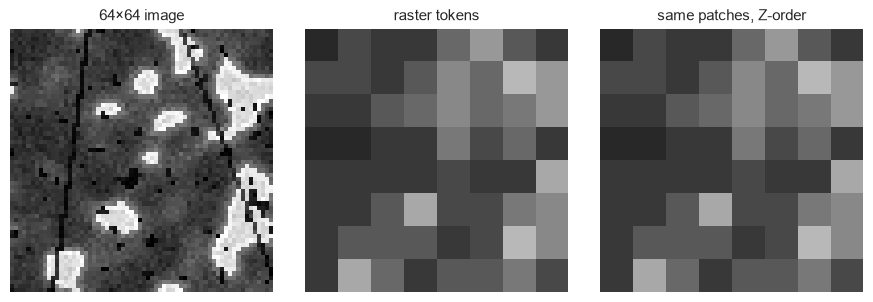

In [33]:
PATCH_SIZE, N_TOKEN_LEVELS = 8, 16
GRID_SIZE = CONFIG.image_size // PATCH_SIZE
assert CONFIG.image_size % PATCH_SIZE == 0 and GRID_SIZE == 8

def morton_index(y: int, x: int, bits: int = 3) -> int:
    value = 0
    for bit in range(bits):
        value |= ((x >> bit) & 1) << (2 * bit)
        value |= ((y >> bit) & 1) << (2 * bit + 1)
    return value

raster_order = np.arange(GRID_SIZE ** 2)
morton_order = np.argsort([
    morton_index(y, x) for y in range(GRID_SIZE) for x in range(GRID_SIZE)
])
assert sorted(morton_order.tolist()) == raster_order.tolist()

def tokenise(batch_images: np.ndarray, order: np.ndarray) -> np.ndarray:
    x = np.asarray(batch_images)[:, 0]
    patch_means = x.reshape(-1, GRID_SIZE, PATCH_SIZE, GRID_SIZE, PATCH_SIZE).mean(axis=(2, 4))
    tokens_grid = np.clip((patch_means * N_TOKEN_LEVELS).astype(int), 0, N_TOKEN_LEVELS - 1)
    return tokens_grid.reshape(len(x), -1)[:, order]

def detokenise(token_sequence: np.ndarray, order: np.ndarray) -> np.ndarray:
    flat = np.empty(GRID_SIZE ** 2, dtype=float)
    flat[order] = (np.asarray(token_sequence) + .5) / N_TOKEN_LEVELS
    coarse = flat.reshape(GRID_SIZE, GRID_SIZE)
    return np.kron(coarse, np.ones((PATCH_SIZE, PATCH_SIZE)))

raster_tokens = tokenise(images, raster_order)
morton_tokens = tokenise(images, morton_order)
grain_mu, grain_sd = synthetic.loc[train_idx, "grain_size"].agg(["mean", "std"])
yield_mu, yield_sd = synthetic.loc[train_idx, "yield_strength"].agg(["mean", "std"])
ar_condition = np.column_stack([
    np.eye(5, dtype=np.float32)[synthetic.regime_id.to_numpy()],
    ((synthetic.grain_size - grain_mu) / grain_sd).to_numpy(),
    ((synthetic.yield_strength - yield_mu) / yield_sd).to_numpy(),
]).astype(np.float32)
print("tokens", raster_tokens.shape, "conditions", ar_condition.shape,
      "first raster tokens", raster_tokens[0, :12])

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(images[0,0], cmap="gray", vmin=0, vmax=1); axes[0].set_title("64×64 image")
axes[1].imshow(detokenise(raster_tokens[0], raster_order), cmap="gray", vmin=0, vmax=1); axes[1].set_title("raster tokens")
axes[2].imshow(detokenise(morton_tokens[0], morton_order), cmap="gray", vmin=0, vmax=1); axes[2].set_title("same patches, Z-order")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

In [34]:
BOS_TOKEN = N_TOKEN_LEVELS

class ConditionalTokenGRU(nn.Module):
    def __init__(self, condition_dim: int, embedding_dim: int = 20, hidden_dim: int = 56):
        super().__init__()
        self.embedding = nn.Embedding(N_TOKEN_LEVELS + 1, embedding_dim)
        self.gru = nn.GRU(embedding_dim + condition_dim, hidden_dim, batch_first=True)
        self.output = nn.Linear(hidden_dim, N_TOKEN_LEVELS)
    def forward(self, input_tokens, condition):
        emb = self.embedding(input_tokens)
        repeated_condition = condition[:, None, :].expand(-1, input_tokens.shape[1], -1)
        hidden, _ = self.gru(torch.cat([emb, repeated_condition], dim=-1))
        return self.output(hidden)

def train_token_model(tokens: np.ndarray, epochs: int) -> tuple[ConditionalTokenGRU, list[float]]:
    inputs = np.concatenate([
        np.full((len(tokens), 1), BOS_TOKEN), tokens[:, :-1]
    ], axis=1)
    dataset = TensorDataset(
        torch.tensor(inputs, dtype=torch.long), torch.tensor(tokens, dtype=torch.long),
        torch.tensor(ar_condition),
    )
    sampler = torch.utils.data.Subset(dataset, train_idx.tolist())
    loader = DataLoader(sampler, batch_size=CONFIG.batch_size, shuffle=True)
    model = ConditionalTokenGRU(ar_condition.shape[1]).to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=2e-3)
    history = []
    for _ in range(epochs):
        model.train(); total_loss = 0.0; seen = 0
        for input_b, target_b, condition_b in loader:
            input_b, target_b, condition_b = input_b.to(DEVICE), target_b.to(DEVICE), condition_b.to(DEVICE)
            optimiser.zero_grad(); logits = model(input_b, condition_b)
            loss = F.cross_entropy(logits.reshape(-1, N_TOKEN_LEVELS), target_b.reshape(-1))
            loss.backward(); optimiser.step()
            total_loss += loss.item() * len(input_b); seen += len(input_b)
        history.append(total_loss / seen)
    return model, history

ar_epochs = 8 if CONFIG.fast_demo else 20
raster_ar, raster_history = train_token_model(raster_tokens, ar_epochs)
morton_ar, morton_history = train_token_model(morton_tokens, ar_epochs)
print("raster cross-entropy", np.round(raster_history, 4))
print("Morton cross-entropy", np.round(morton_history, 4))

def token_cross_entropy(model, tokens, indices):
    inputs = np.concatenate([np.full((len(tokens), 1), BOS_TOKEN), tokens[:, :-1]], axis=1)
    with torch.no_grad():
        logits = model(torch.tensor(inputs[indices], dtype=torch.long, device=DEVICE),
                       torch.tensor(ar_condition[indices], device=DEVICE))
    return F.cross_entropy(logits.reshape(-1, N_TOKEN_LEVELS),
                           torch.tensor(tokens[indices].reshape(-1), dtype=torch.long, device=DEVICE)).item()

print("validation CE raster=%.3f, Morton=%.3f" % (
    token_cross_entropy(raster_ar, raster_tokens, val_idx),
    token_cross_entropy(morton_ar, morton_tokens, val_idx),
))
test_inputs = torch.tensor(np.concatenate([
    np.full((2,1), BOS_TOKEN), raster_tokens[val_idx[:2], :-1]
], axis=1), dtype=torch.long, device=DEVICE)
with torch.no_grad():
    shape_logits = raster_ar(test_inputs, torch.tensor(ar_condition[val_idx[:2]], device=DEVICE))
print("AR forward shapes:", tuple(test_inputs.shape), "+", tuple(ar_condition[val_idx[:2]].shape), "→", tuple(shape_logits.shape))

raster cross-entropy [2.6455 2.4066 2.3448 2.3194 2.3036 2.2944 2.289  2.2851]
Morton cross-entropy [2.6564 2.4181 2.3407 2.3104 2.2964 2.2883 2.2844 2.282 ]
validation CE raster=2.309, Morton=2.306
AR forward shapes: (2, 64) + (2, 7) → (2, 64, 16)


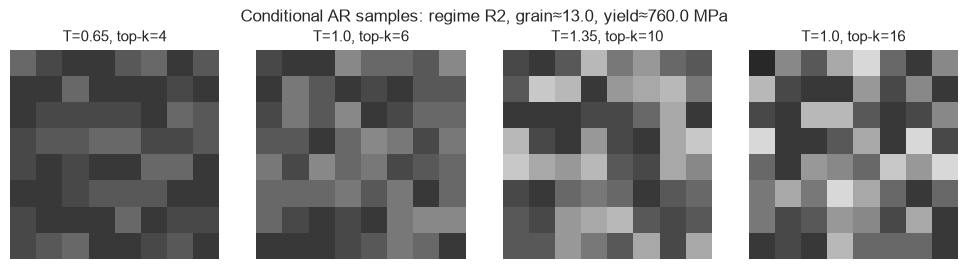

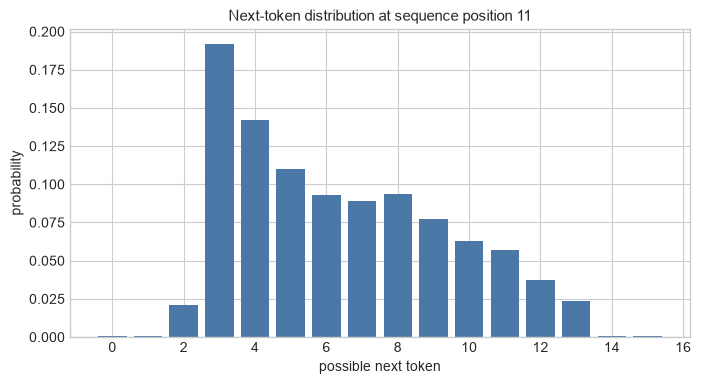

In [35]:
def sample_tokens(model, condition: np.ndarray, *, temperature=1.0, top_k=6, seed=0):
    torch.manual_seed(seed)
    model.eval()
    sequence = torch.full((1, 1), BOS_TOKEN, dtype=torch.long, device=DEVICE)
    condition_t = torch.tensor(condition[None], dtype=torch.float32, device=DEVICE)
    next_probability_history = []
    for _ in range(GRID_SIZE ** 2):
        with torch.no_grad():
            logits = model(sequence, condition_t)[:, -1] / temperature
        values, indices = torch.topk(logits, k=min(top_k, N_TOKEN_LEVELS), dim=-1)
        restricted = torch.softmax(values, dim=-1)
        selected = torch.multinomial(restricted, 1)
        next_token = indices.gather(1, selected)
        probability = torch.zeros_like(logits).scatter(1, indices, restricted)
        next_probability_history.append(probability.cpu().numpy()[0])
        sequence = torch.cat([sequence, next_token], dim=1)
    return sequence[0, 1:].cpu().numpy(), np.stack(next_probability_history)

desired_regime, desired_grain, desired_yield = 2, 13.0, 760.0
desired_condition = np.r_[
    np.eye(5)[desired_regime], (desired_grain-grain_mu)/grain_sd, (desired_yield-yield_mu)/yield_sd
].astype(np.float32)
sampling_specs = [(.65, 4), (1.0, 6), (1.35, 10), (1.0, 16)]
fig, axes = plt.subplots(1, 4, figsize=(10, 2.7))
generated_ar = []
for i, ((temperature, top_k), ax) in enumerate(zip(sampling_specs, axes)):
    tokens, probabilities = sample_tokens(raster_ar, desired_condition,
                                           temperature=temperature, top_k=top_k,
                                           seed=CONFIG.seed+i)
    image_ar = detokenise(tokens, raster_order); generated_ar.append(image_ar)
    ax.imshow(image_ar, cmap="gray", vmin=0, vmax=1); ax.axis("off")
    ax.set_title(f"T={temperature}, top-k={top_k}")
plt.suptitle(f"Conditional AR samples: regime R{desired_regime}, grain≈{desired_grain}, yield≈{desired_yield} MPa")
plt.tight_layout(); plt.show()

plt.bar(np.arange(N_TOKEN_LEVELS), probabilities[10], color="#4C78A8")
plt.xlabel("possible next token"); plt.ylabel("probability"); plt.title("Next-token distribution at sequence position 11")
plt.show()

Raster and Morton order factorise the same 2D object differently; neither is a physical
growth law. Temperature sampling flattens or sharpens token probabilities, while top-k
deletes the long tail. The blocky images reflect the tokeniser's information bottleneck,
not merely a weak GRU.

<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** Cross-entropy measures next-token probability, not metallurgical
validity. The blockiness comes from the tokeniser before the GRU is even trained. Exposure
bias explains why good teacher-forced loss can coexist with drifting generated sequences.

**Conditioning test.** Generate many samples under two substantially different target
conditions and compare their morphology distributions. A label printed above unchanged
samples is not successful conditioning.

**Guided exercise.** Replace 8×8 patches with 4×4 patches. Predict the trade-off among
sequence length, boundary detail, training time, and long-range consistency.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> The GRU learns local token regularities and responds to processing/property conditioning.<br>
<b>What did it fail to learn?</b> Patch means discard grain boundaries and a one-dimensional order introduces arbitrary spatial asymmetry.<br>
<b>What would falsify our interpretation?</b> If shuffled conditions yield identical conditional statistics, the claimed conditioning has failed.<br>
<b>What should I try next?</b> Use a learned vector-quantised codebook and compare raster, Morton, and random token order under equal compute.
</div>

## Part 10 — Conditional diffusion modelling

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** Forward diffusion is a known corruption process. Learning focuses on
predicting the noise that was added at a randomly selected time. Generation starts from
noise and repeatedly applies those learned corrections.

**Follow the code.** `alpha_bars` controls retained signal. The denoiser receives noisy
pixels, a sinusoidal timestep code, and scaled process/property conditions. The reverse
loop implements the DDPM mean and variance update across 30 steps.

**Pause and predict.** Early reverse steps should establish coarse intensity regions;
later steps should refine local structure. Multiple seeds under one condition should yield
different images but similar conditional morphology statistics.

Diffusion is presented as an important generative method, not as a neuroscience model.
For CPU execution we diffuse 16×16 grayscale images with 30 timesteps and a small MLP.
Its outputs are educational coarse microstructures; morphology metrics matter more than
visual persuasion.

In [36]:
explain_equation(
    r"x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\,\epsilon,\quad \epsilon\sim\mathcal{N}(0,I)",
    {"x_0": "clean microstructure", "x_t": "noisy state at timestep t", r"\bar\alpha_t": "cumulative retained signal", r"\epsilon": "Gaussian noise"},
    {"x_t": "[batch,1,16,16]", "t": "[batch]", r"\epsilon": "same as x"},
    random="Gaussian ε and sampled timestep t.",
    fixed="Clean training image and prescribed noise schedule.",
    optimised="Denoiser parameters learn to predict ε from x_t, t, and condition.",
    materials_analogy="Learn a field of corrections that turns noise into one of many structures compatible with requested process/property conditions."
)

### Equation lens

$$ x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\,\epsilon,\quad \epsilon\sim\mathcal{N}(0,I) $$

- **$x_0$** — clean microstructure; shape `scalar`
- **$x_t$** — noisy state at timestep t; shape `[batch,1,16,16]`
- **$\bar\alpha_t$** — cumulative retained signal; shape `scalar`
- **$\epsilon$** — Gaussian noise; shape `same as x`

- **Random:** Gaussian ε and sampled timestep t.
- **Fixed/observed:** Clean training image and prescribed noise schedule.
- **Optimised:** Denoiser parameters learn to predict ε from x_t, t, and condition.
- **Materials interpretation:** Learn a field of corrections that turns noise into one of many structures compatible with requested process/property conditions.

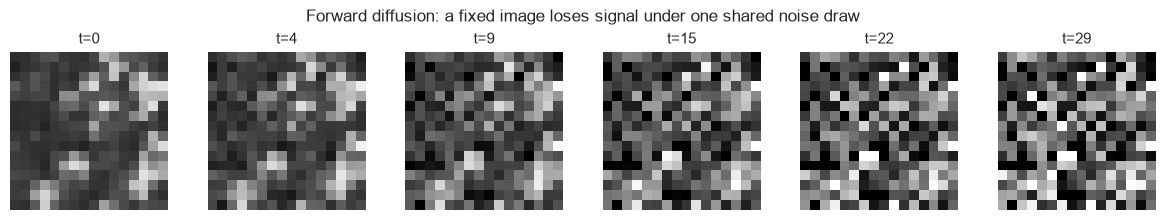

In [37]:
DIFF_SIZE, DIFF_STEPS = 16, 30
diff_images = F.interpolate(image_tensor, size=(DIFF_SIZE, DIFF_SIZE), mode="area") * 2 - 1
diff_condition_columns = ["processing_temperature", "cooling_rate", "phase_fraction", "yield_strength", "ductility"]
diff_condition_scaler = StandardScaler().fit(synthetic.loc[train_idx, diff_condition_columns])
diff_conditions = diff_condition_scaler.transform(synthetic[diff_condition_columns]).astype(np.float32)
betas = torch.linspace(5e-4, 0.035, DIFF_STEPS, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x0, timesteps, noise=None):
    noise = torch.randn_like(x0) if noise is None else noise
    a_bar = alpha_bars[timesteps].view(-1, 1, 1, 1)
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1-a_bar) * noise, noise

base = diff_images[[0]].to(DEVICE)
shared_noise = torch.randn_like(base)
fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
for ax, t in zip(axes, [0, 4, 9, 15, 22, 29]):
    noisy_t, _ = q_sample(base, torch.tensor([t], device=DEVICE), shared_noise)
    ax.imshow(noisy_t[0,0].cpu(), cmap="gray", vmin=-1, vmax=1); ax.axis("off"); ax.set_title(f"t={t}")
plt.suptitle("Forward diffusion: a fixed image loses signal under one shared noise draw")
plt.tight_layout(); plt.show()

In [38]:
def sinusoidal_time_embedding(timesteps: torch.Tensor, dimension: int = 20) -> torch.Tensor:
    half = dimension // 2
    frequencies = torch.exp(-math.log(10_000) * torch.arange(half, device=timesteps.device) / max(half-1, 1))
    angles = timesteps.float()[:, None] * frequencies[None]
    return torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)

class TinyConditionalDenoiser(nn.Module):
    def __init__(self, condition_dim: int, pixels: int = DIFF_SIZE*DIFF_SIZE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(pixels + 20 + condition_dim, 384), nn.SiLU(),
            nn.Linear(384, 384), nn.SiLU(), nn.Linear(384, pixels),
        )
    def forward(self, x_t, timesteps, condition):
        flat = x_t.flatten(1)
        time_code = sinusoidal_time_embedding(timesteps, 20)
        predicted_noise = self.net(torch.cat([flat, time_code, condition], dim=1))
        return predicted_noise.view_as(x_t)

denoiser = TinyConditionalDenoiser(len(diff_condition_columns)).to(DEVICE)
diffusion_opt = torch.optim.Adam(denoiser.parameters(), lr=2e-3)
diff_dataset = TensorDataset(diff_images[train_idx], torch.tensor(diff_conditions[train_idx]))
diff_loader = DataLoader(diff_dataset, batch_size=CONFIG.batch_size, shuffle=True)
diffusion_history = []
for epoch in range(25 if CONFIG.fast_demo else 60):
    denoiser.train(); losses = []
    for x0, condition in diff_loader:
        x0, condition = x0.to(DEVICE), condition.to(DEVICE)
        t = torch.randint(0, DIFF_STEPS, (len(x0),), device=DEVICE)
        x_t, noise = q_sample(x0, t)
        diffusion_opt.zero_grad(); predicted_noise = denoiser(x_t, t, condition)
        loss = F.mse_loss(predicted_noise, noise)
        loss.backward(); diffusion_opt.step(); losses.append(loss.item())
    diffusion_history.append(np.mean(losses))
print("diffusion epsilon-prediction MSE:", np.round(diffusion_history, 4))
print("denoiser shapes:", tuple(x_t.shape), "+ t", tuple(t.shape), "+ c", tuple(condition.shape), "→", tuple(predicted_noise.shape))

diffusion epsilon-prediction MSE: [0.9971 0.9711 0.9466 0.9149 0.8853 0.8518 0.8294 0.7992 0.792  0.7695
 0.7489 0.7336 0.7166 0.6898 0.6937 0.6738 0.6645 0.6576 0.6568 0.6488
 0.6341 0.6184 0.6257 0.6064 0.6045]
denoiser shapes: (46, 1, 16, 16) + t (46,) + c (46, 5) → (46, 1, 16, 16)


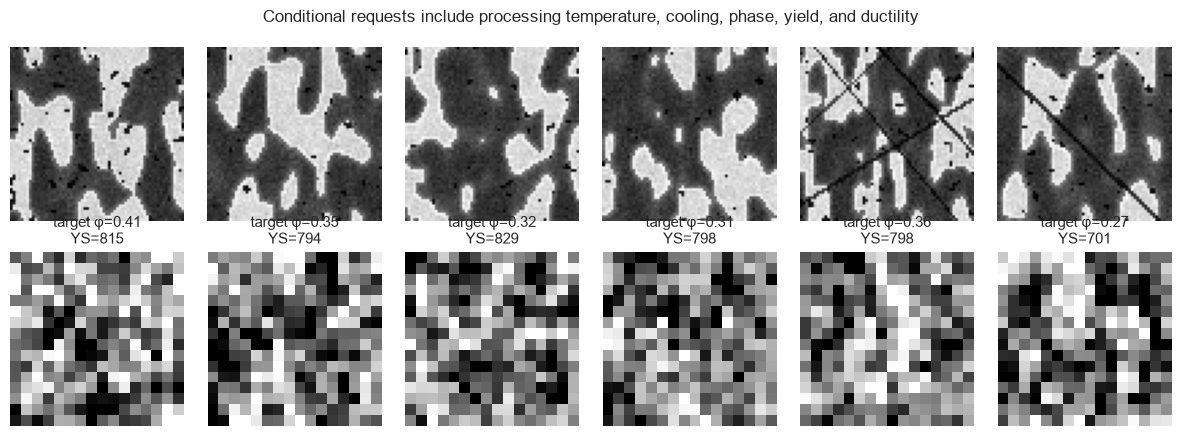

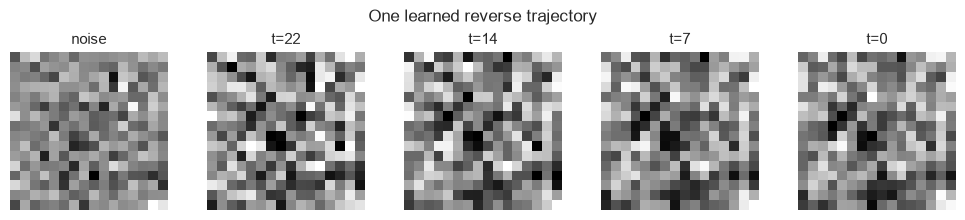

In [39]:
@torch.no_grad()
def reverse_diffusion(condition_array: np.ndarray, seed: int = 0):
    torch.manual_seed(seed)
    denoiser.eval()
    condition = torch.tensor(condition_array, dtype=torch.float32, device=DEVICE)
    x = torch.randn((len(condition), 1, DIFF_SIZE, DIFF_SIZE), device=DEVICE)
    snapshots = {DIFF_STEPS: x.cpu().numpy().copy()}
    for t_int in reversed(range(DIFF_STEPS)):
        t = torch.full((len(condition),), t_int, dtype=torch.long, device=DEVICE)
        eps_hat = denoiser(x, t, condition)
        alpha_t, beta_t, a_bar_t = alphas[t_int], betas[t_int], alpha_bars[t_int]
        mean = (x - beta_t / torch.sqrt(1-a_bar_t) * eps_hat) / torch.sqrt(alpha_t)
        if t_int > 0:
            a_bar_prev = alpha_bars[t_int-1]
            posterior_variance = beta_t * (1-a_bar_prev) / (1-a_bar_t)
            x = mean + torch.sqrt(posterior_variance.clamp_min(1e-8)) * torch.randn_like(x)
        else:
            x = mean
        x = x.clamp(-1.5, 1.5)
        if t_int in {22, 14, 7, 0}:
            snapshots[t_int] = x.cpu().numpy().copy()
    return ((x.clamp(-1,1)+1)/2).cpu().numpy(), snapshots

target_rows = synthetic.loc[val_idx[:6], diff_condition_columns].copy()
# Treat these rows as desired conditions. Same target can admit multiple images via random seeds.
desired_scaled = diff_condition_scaler.transform(target_rows).astype(np.float32)
generated_diff, reverse_snapshots = reverse_diffusion(desired_scaled, seed=CONFIG.seed)

fig, axes = plt.subplots(2, 6, figsize=(12, 4.4))
for col, idx in enumerate(val_idx[:6]):
    axes[0,col].imshow(images[idx,0], cmap="gray", vmin=0, vmax=1); axes[0,col].axis("off")
    axes[1,col].imshow(generated_diff[col,0], cmap="gray", vmin=0, vmax=1); axes[1,col].axis("off")
    axes[1,col].set_title(f"target φ={target_rows.iloc[col].phase_fraction:.2f}\nYS={target_rows.iloc[col].yield_strength:.0f}")
axes[0,0].set_ylabel("reference"); axes[1,0].set_ylabel("generated")
plt.suptitle("Conditional requests include processing temperature, cooling, phase, yield, and ductility")
plt.tight_layout(); plt.show()

snapshot_keys = [DIFF_STEPS, 22, 14, 7, 0]
fig, axes = plt.subplots(1, len(snapshot_keys), figsize=(10, 2.2))
for ax, key in zip(axes, snapshot_keys):
    ax.imshow(reverse_snapshots[key][0,0], cmap="gray"); ax.axis("off"); ax.set_title("noise" if key==DIFF_STEPS else f"t={key}")
plt.suptitle("One learned reverse trajectory"); plt.tight_layout(); plt.show()

In [40]:
# Evaluate by morphology and a baseline forward model, not appearance alone.
upsampled_generated = F.interpolate(torch.tensor(generated_diff), size=(CONFIG.image_size, CONFIG.image_size), mode="bilinear", align_corners=False).numpy()
generated_features = pd.DataFrame([morphology_features(x) for x in upsampled_generated])
predicted_generated_properties = forest_model.predict(
    generated_features[MORPH_NAMES].to_numpy(np.float32)
)
diffusion_evaluation = pd.DataFrame({
    "target phase": target_rows.phase_fraction.to_numpy(),
    "generated phase proxy": generated_features.phase_fraction_approx,
    "generated autocorr": generated_features.spatial_autocorr,
    "target yield": target_rows.yield_strength.to_numpy(),
    "forward-model yield": predicted_generated_properties[:,0],
    "target ductility": target_rows.ductility.to_numpy(),
    "forward-model ductility": predicted_generated_properties[:,2],
})
display(diffusion_evaluation.round(3))
pairwise_diversity = pairwise_distances(generated_diff.reshape(len(generated_diff), -1))
print("mean pairwise pixel diversity=%.3f" % pairwise_diversity[np.triu_indices_from(pairwise_diversity, 1)].mean())
print("Caution: the forward model is itself synthetic and fallible; this is consistency checking, not validation.")

,target phase,generated phase proxy,generated autocorr,target yield,forward-model yield,target ductility,forward-model ductility
0,0.407,0.456,0.950,814.629,866.101,23.843,19.969
1,0.354,0.390,0.959,794.479,788.299,23.085,21.885
2,0.322,0.393,0.956,829.280,795.487,23.785,22.052
3,0.312,0.389,0.954,797.525,788.824,22.481,21.944
4,0.358,0.420,0.954,798.027,852.268,17.357,21.016
5,0.270,0.389,0.955,700.626,785.921,26.554,21.728


mean pairwise pixel diversity=6.732
Caution: the forward model is itself synthetic and fallible; this is consistency checking, not validation.


<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** Falling epsilon MSE shows the denoising task is learned, but not
that generated images are physically valid. The evaluation therefore compares phase proxy,
autocorrelation, forward-model properties, and diversity—not appearance alone.

**Why multimodality matters.** One target hardness can correspond to many spatially
different microstructures. Diffusion can represent that one-to-many mapping, whereas an
MSE image regressor tends to average valid alternatives into blur.

**Guided exercise.** Fix one condition, generate 100 seeds, and compare morphology
histograms with real/synthetic reference images. Also check nearest-training-image distance
to distinguish diversity from memorisation.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> The denoiser learns timestep- and condition-dependent corrections and can produce diverse coarse structures.<br>
<b>What did it fail to learn?</b> A 16×16, three-epoch MLP does not reproduce real grain boundaries or prove property-conditioned inverse design.<br>
<b>What would falsify our interpretation?</b> Failure to match held-out morphology distributions—or nearest-neighbour copying—would falsify useful generation.<br>
<b>What should I try next?</b> Generate many samples for one condition and compare phase, correlation, diversity, and nearest-training-image distance.
</div>

## Part 11 — Uncertainty, extremes, and calibration

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** Aleatoric uncertainty describes unresolved variation/noise under a
model; epistemic uncertainty describes limited knowledge of the mapping; OOD uncertainty
is the challenge of recognising that a new case lies outside training support.

**Follow the code.** Quantile models target interval endpoints directly. A Gaussian neural
regressor predicts mean and variance. A five-member forest ensemble turns disagreement
into an epistemic proxy. Calibration asks whether nominal intervals achieve empirical coverage.

**Pause and predict.** Validation coverage should be closer to ideal than OOD coverage.
Extreme targets should have larger error because mean/median objectives shrink rare values
toward the centre.

Mean-squared error rewards conditional means, so rare extremes are often pulled inward.
We compare mean, quantile, heteroscedastic Gaussian, and ensemble predictions for yield
strength. Synthetic labels make calibration testable; seven real hardness conditions do not.

In [41]:
yield_target = y[:, 0]
mean_regressor = GradientBoostingRegressor(
    loss="squared_error", n_estimators=120, max_depth=2, random_state=CONFIG.seed
).fit(X[train_idx], yield_target[train_idx])
lower_regressor = GradientBoostingRegressor(
    loss="quantile", alpha=.10, n_estimators=120, max_depth=2, random_state=CONFIG.seed
).fit(X[train_idx], yield_target[train_idx])
median_regressor = GradientBoostingRegressor(
    loss="quantile", alpha=.50, n_estimators=120, max_depth=2, random_state=CONFIG.seed
).fit(X[train_idx], yield_target[train_idx])
upper_regressor = GradientBoostingRegressor(
    loss="quantile", alpha=.90, n_estimators=120, max_depth=2, random_state=CONFIG.seed
).fit(X[train_idx], yield_target[train_idx])

class GaussianPropertyRegressor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(n_features, 32), nn.SiLU(), nn.Linear(32, 24), nn.SiLU())
        self.output = nn.Linear(24, 2)
    def forward(self, x):
        out = self.output(self.shared(x))
        return out[:, :1], torch.clamp(out[:, 1:], -5, 3)

yield_scaler = StandardScaler().fit(yield_target[train_idx, None])
gaussian_model = GaussianPropertyRegressor(X.shape[1]).to(DEVICE)
gaussian_opt = torch.optim.Adam(gaussian_model.parameters(), lr=3e-3)
gaussian_data = TensorDataset(
    torch.tensor(x_scaler.transform(X[train_idx]), dtype=torch.float32),
    torch.tensor(yield_scaler.transform(yield_target[train_idx, None]), dtype=torch.float32),
)
gaussian_loader = DataLoader(gaussian_data, batch_size=CONFIG.batch_size, shuffle=True)
for _ in range(30 if CONFIG.fast_demo else 100):
    for xb, yb in gaussian_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE); gaussian_opt.zero_grad()
        mu, logvar = gaussian_model(xb)
        nll = .5 * torch.mean(torch.exp(-logvar) * (yb-mu)**2 + logvar)
        nll.backward(); gaussian_opt.step()

ensemble = []
for seed in range(5):
    member = RandomForestRegressor(
        n_estimators=60, min_samples_leaf=3, max_features=.75,
        bootstrap=True, random_state=CONFIG.seed+seed, n_jobs=-1,
    ).fit(X[train_idx], yield_target[train_idx])
    ensemble.append(member)

def gaussian_prediction(indices):
    with torch.no_grad():
        mu_s, logvar_s = gaussian_model(torch.tensor(
            x_scaler.transform(X[indices]), dtype=torch.float32, device=DEVICE
        ))
    mu = yield_scaler.inverse_transform(mu_s.cpu().numpy()).ravel()
    std = np.exp(.5*logvar_s.cpu().numpy().ravel()) * yield_scaler.scale_[0]
    return mu, std

print("Gaussian forward shapes: [batch,features] → mean/log-variance [batch,1]")

Gaussian forward shapes: [batch,features] → mean/log-variance [batch,1]


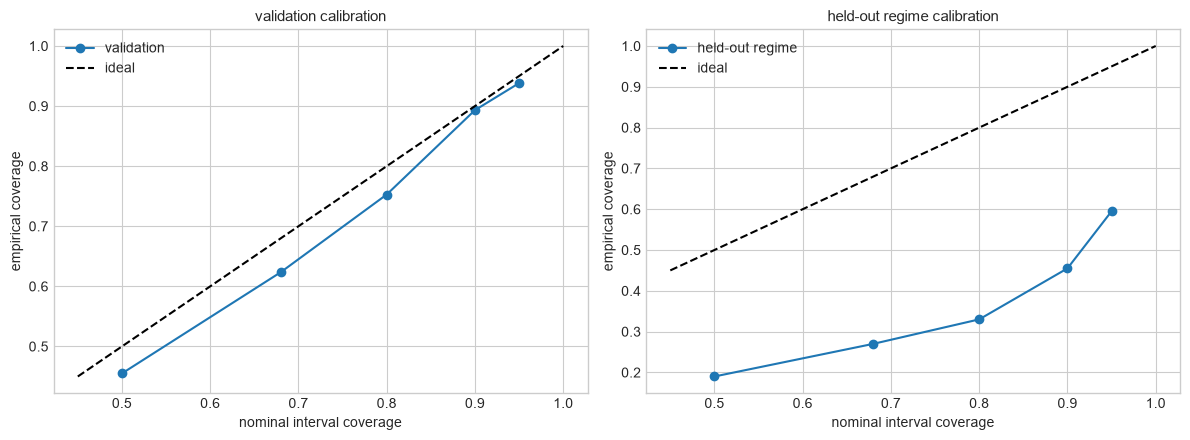

,split,mean aleatoric std,mean epistemic std,RMSE
0,validation,30.10,3.06,32.24
1,held-out regime,39.11,5.22,77.61


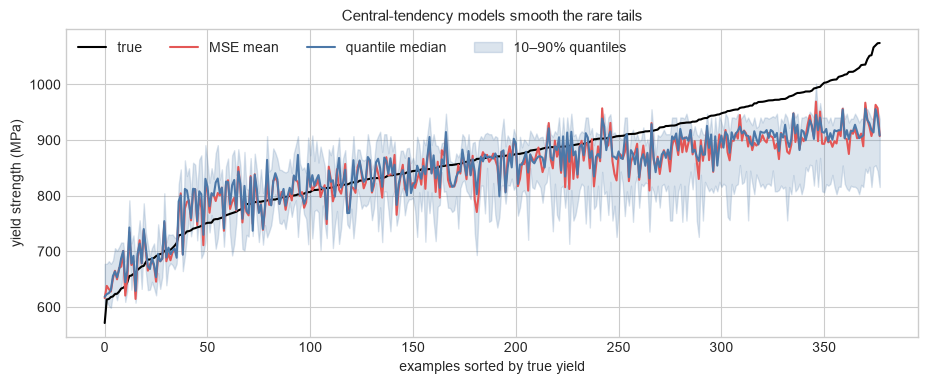

In [42]:
import statistics

calibration_rows = []
uncertainty_summary = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (split, idx) in zip(axes, [("validation", val_idx), ("held-out regime", ood_idx)]):
    mu, aleatoric_std = gaussian_prediction(idx)
    member_predictions = np.stack([member.predict(X[idx]) for member in ensemble])
    epistemic_std = member_predictions.std(axis=0)
    combined_std = np.sqrt(aleatoric_std**2 + epistemic_std**2)
    nominal_levels = np.array([.50, .68, .80, .90, .95])
    empirical = []
    for nominal in nominal_levels:
        z_value = statistics.NormalDist().inv_cdf((1+nominal)/2)
        covered = np.abs(yield_target[idx]-mu) <= z_value*combined_std
        empirical.append(covered.mean())
        calibration_rows.append({"split": split, "nominal": nominal, "empirical": covered.mean()})
    ax.plot(nominal_levels, empirical, marker="o", label=split)
    ax.plot([.45,1], [.45,1], "--", color="black", label="ideal")
    ax.set(xlabel="nominal interval coverage", ylabel="empirical coverage", title=f"{split} calibration")
    ax.legend()
    uncertainty_summary.append({
        "split": split, "mean aleatoric std": aleatoric_std.mean(),
        "mean epistemic std": epistemic_std.mean(), "RMSE": mean_squared_error(yield_target[idx], mu)**.5,
    })
plt.tight_layout(); plt.show()
display(pd.DataFrame(uncertainty_summary).round(2))

all_eval = np.concatenate([val_idx, ood_idx])
prediction_mean = mean_regressor.predict(X[all_eval])
q10, q50, q90 = [m.predict(X[all_eval]) for m in (lower_regressor, median_regressor, upper_regressor)]
order = np.argsort(yield_target[all_eval])
plt.figure(figsize=(11,4))
plt.plot(yield_target[all_eval][order], label="true", color="black", lw=1.5)
plt.plot(prediction_mean[order], label="MSE mean", color="#E45756")
plt.plot(q50[order], label="quantile median", color="#4C78A8")
plt.fill_between(np.arange(len(order)), q10[order], q90[order], color="#4C78A8", alpha=.2, label="10–90% quantiles")
plt.xlabel("examples sorted by true yield"); plt.ylabel("yield strength (MPa)")
plt.title("Central-tendency models smooth the rare tails"); plt.legend(ncol=4); plt.show()

In [43]:
threshold_low, threshold_high = np.quantile(yield_target[all_eval], [.10, .90])
tail_mask = (yield_target[all_eval] <= threshold_low) | (yield_target[all_eval] >= threshold_high)
tail_table = pd.DataFrame([
    {"region": "central 80%", "n": int((~tail_mask).sum()),
     "MSE-model MAE": mean_absolute_error(yield_target[all_eval][~tail_mask], prediction_mean[~tail_mask]),
     "median-model MAE": mean_absolute_error(yield_target[all_eval][~tail_mask], q50[~tail_mask])},
    {"region": "extreme 20%", "n": int(tail_mask.sum()),
     "MSE-model MAE": mean_absolute_error(yield_target[all_eval][tail_mask], prediction_mean[tail_mask]),
     "median-model MAE": mean_absolute_error(yield_target[all_eval][tail_mask], q50[tail_mask])},
])
display(tail_table.round(2))
print("Aleatoric: irreducible image/property noise under the model.")
print("Epistemic: disagreement caused by limited model/data knowledge.")
print("OOD uncertainty: uncertainty under distribution shift; ordinary ensembles may still be overconfident.")

,region,n,MSE-model MAE,median-model MAE
0,central 80%,302,35.79,33.34
1,extreme 20%,76,65.64,63.79


Aleatoric: irreducible image/property noise under the model.
Epistemic: disagreement caused by limited model/data knowledge.
OOD uncertainty: uncertainty under distribution shift; ordinary ensembles may still be overconfident.


<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** A narrow interval is not good if it misses the truth. The held-out
calibration curve exposes overconfidence under shift even when the model reports greater
uncertainty. Tail MAE makes central-tendency smoothing explicit.

**Repository connection.** Seven hardness conditions cannot support a trustworthy
calibration curve. For UHCS, leave-one-condition-out results are feasibility estimates and
should report individual errors rather than smooth reliability graphics.

**Guided exercise.** Calibrate an interval multiplier on validation data, then apply it
unchanged to the OOD regime. Explain why validation calibration cannot guarantee shift coverage.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> Different objectives expose intervals, heteroscedastic noise, model disagreement, and tail shrinkage.<br>
<b>What did it fail to learn?</b> Synthetic calibration does not transfer automatically to real hardness, especially at n=7.<br>
<b>What would falsify our interpretation?</b> Intervals that miss their nominal coverage on held-out regimes falsify calibration claims.<br>
<b>What should I try next?</b> Conformalise intervals by processing group and compare coverage with the Gaussian approximation.
</div>

## Part 12 — Latent world models and processing-sequence planning

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** A direct property model answers “what property follows from this input?”
A world model answers “how does state change under an action?” Repeating the second answer
creates a simulated future on which planning can operate.

**Follow the code.** Synthetic trajectories contain current state, action, next state, and
next properties. One model predicts next physical state; another compresses to three latent
variables, transitions there, then decodes state/properties. Splits hold out whole trajectories.

**Pause and predict.** One-step transition error can be small while rollout error grows
with horizon. The highest-yield sequence may repeat quenching, but a richer simulator would
eventually penalise accumulated stress, energy, time, or impossible phase kinetics.

A forward property model predicts an endpoint. A transition model predicts how state
changes. A latent world model compresses state, transitions in latent space, and predicts
future state/properties. Rollouts expose compounding error that one-step metrics hide.

In [44]:
import itertools

WORLD_STATES = ["grain_size", "phase_fraction", "porosity", "anisotropy", "defect_density"]
WORLD_ACTIONS = ["heat", "quench", "slow cool", "anneal", "deform"]

def world_properties(state: np.ndarray) -> np.ndarray:
    state = np.atleast_2d(state)
    grain, phase, pore, anis, defects = state.T
    ys = 330 + 1_150/np.sqrt(np.clip(grain, 1, None)) + 510*phase - 1_050*pore + 75*anis - 22*defects
    hv = 55 + .29*ys + 125*phase**1.6 + 18*anis - 70*pore
    duct = np.clip(36 - .016*ys - 7.5*phase - 17*pore + .30*grain - .8*defects, 1.5, 38)
    return np.column_stack([ys, hv, duct])

def process_transition(state: np.ndarray, action: int, rng: np.random.Generator) -> np.ndarray:
    grain, phase, pore, anis, defects = state.astype(float)
    if action == 0:      # heat: coarsen, transform, slight pore risk
        grain *= 1.12; phase += .025; pore += .006
    elif action == 1:    # quench: refine/transform, add stress defects
        grain *= .91; phase += .10; anis += .035; defects += .35
    elif action == 2:    # slow cool: coarsen and soften phase
        grain *= 1.07; phase -= .055; defects -= .12
    elif action == 3:    # anneal: recover defects and anisotropy
        grain *= 1.035; anis *= .88; defects *= .72; pore *= .98
    elif action == 4:    # deform: refine but add anisotropy/defects
        grain *= .94; anis += .10; defects += .55
    noise = rng.normal([0,0,0,0,0], [.20,.008,.002,.008,.06])
    return np.array([
        np.clip(grain+noise[0], 2, 35), np.clip(phase+noise[1], .01,.99),
        np.clip(pore+noise[2], .001,.40), np.clip(anis+noise[3], 0,1),
        np.clip(defects+noise[4], 0,12),
    ])

rng = np.random.default_rng(CONFIG.seed)
transition_rows = []
trajectories = {}
n_trajectories, horizon = (260, 6) if CONFIG.fast_demo else (1_000, 10)
starts = synthetic.sample(n_trajectories, replace=True, random_state=CONFIG.seed)[WORLD_STATES].to_numpy()
for trajectory_id, initial in enumerate(starts):
    state = initial.copy(); trajectory = [state.copy()]
    actions = rng.integers(0, len(WORLD_ACTIONS), size=horizon)
    for step, action in enumerate(actions):
        next_state = process_transition(state, int(action), rng)
        transition_rows.append({
            "trajectory_id": trajectory_id, "step": step, "action": int(action),
            **{f"state_{k}": v for k,v in zip(WORLD_STATES, state)},
            **{f"next_{k}": v for k,v in zip(WORLD_STATES, next_state)},
            **{f"next_{k}": v for k,v in zip(TARGET_NAMES, world_properties(next_state)[0])},
        })
        state = next_state; trajectory.append(state.copy())
    trajectories[trajectory_id] = {"states": np.stack(trajectory), "actions": actions}
transition_frame = pd.DataFrame(transition_rows)
state_cols = [f"state_{k}" for k in WORLD_STATES]
next_cols = [f"next_{k}" for k in WORLD_STATES]
next_property_cols = [f"next_{k}" for k in TARGET_NAMES]
action_onehot = np.eye(len(WORLD_ACTIONS))[transition_frame.action]
world_input_raw = np.column_stack([transition_frame[state_cols], action_onehot])
world_next_raw = transition_frame[next_cols].to_numpy()
world_property_raw = transition_frame[next_property_cols].to_numpy()
world_split = GroupShuffleSplit(n_splits=1, test_size=.22, random_state=CONFIG.seed)
world_train, world_test = next(world_split.split(world_input_raw, groups=transition_frame.trajectory_id))
print("transition data", world_input_raw.shape, "train/test trajectories disjoint=",
      not set(transition_frame.trajectory_id.iloc[world_train]) & set(transition_frame.trajectory_id.iloc[world_test]))

transition data (1560, 10) train/test trajectories disjoint= True


In [45]:
world_x_scaler = StandardScaler().fit(world_input_raw[world_train])
world_state_scaler = StandardScaler().fit(world_next_raw[world_train])
world_property_scaler = StandardScaler().fit(world_property_raw[world_train])
world_x = world_x_scaler.transform(world_input_raw).astype(np.float32)
world_next = world_state_scaler.transform(world_next_raw).astype(np.float32)
world_prop = world_property_scaler.transform(world_property_raw).astype(np.float32)

class TransitionMLP(nn.Module):
    def __init__(self):
        super().__init__(); self.net = nn.Sequential(nn.Linear(10,48),nn.SiLU(),nn.Linear(48,32),nn.SiLU(),nn.Linear(32,5))
    def forward(self,x): return self.net(x)

class LatentWorldModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(5,16),nn.Tanh(),nn.Linear(16,3))
        self.decoder = nn.Sequential(nn.Linear(3,16),nn.SiLU(),nn.Linear(16,5))
        self.transition = nn.Sequential(nn.Linear(3+5,24),nn.SiLU(),nn.Linear(24,3))
        self.property_head = nn.Sequential(nn.Linear(3,16),nn.SiLU(),nn.Linear(16,3))
    def forward(self, current_state_scaled, action_code):
        z = self.encoder(current_state_scaled)
        z_next = self.transition(torch.cat([z, action_code], dim=1))
        return self.decoder(z_next), self.property_head(z_next), z, z_next

transition_model = TransitionMLP().to(DEVICE)
latent_world = LatentWorldModel().to(DEVICE)
direct_property = RandomForestRegressor(n_estimators=100, min_samples_leaf=2,
                                        random_state=CONFIG.seed, n_jobs=-1).fit(
    world_input_raw[world_train], world_property_raw[world_train]
)
joint_opt = torch.optim.Adam(list(transition_model.parameters())+list(latent_world.parameters()), lr=3e-3)
train_dataset = TensorDataset(
    torch.tensor(world_x[world_train]), torch.tensor(world_next[world_train]),
    torch.tensor(world_prop[world_train]),
    torch.tensor(action_onehot[world_train], dtype=torch.float32),
    torch.tensor(world_state_scaler.transform(transition_frame[state_cols].to_numpy())[world_train], dtype=torch.float32),
)
train_loader = DataLoader(train_dataset, batch_size=CONFIG.batch_size, shuffle=True)
for _ in range(45 if CONFIG.fast_demo else 160):
    for xb, next_b, prop_b, action_b, current_b in train_loader:
        xb, next_b, prop_b = xb.to(DEVICE), next_b.to(DEVICE), prop_b.to(DEVICE)
        action_b, current_b = action_b.to(DEVICE), current_b.to(DEVICE)
        joint_opt.zero_grad()
        transition_prediction = transition_model(xb)
        latent_next, latent_prop, z, z_next = latent_world(current_b, action_b)
        reconstructed_current = latent_world.decoder(z)
        loss = F.mse_loss(transition_prediction,next_b) + F.mse_loss(latent_next,next_b)
        loss += .35*F.mse_loss(latent_prop,prop_b) + .15*F.mse_loss(reconstructed_current,current_b)
        loss.backward(); joint_opt.step()
print("world model shapes: state [B,5] + action [B,5] → latent [B,3] → next state [B,5] + properties [B,3]")

world model shapes: state [B,5] + action [B,5] → latent [B,3] → next state [B,5] + properties [B,3]


,model,MAE yield_strength,MAE hardness,MAE ductility
0,direct supervised property,18.12,7.32,0.60
1,transition model → property equation,5.06,2.34,0.15
2,latent world model property head,8.66,4.39,0.30


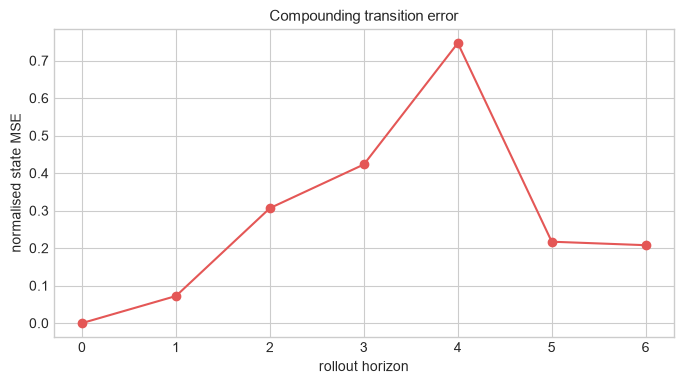

In [46]:
with torch.no_grad():
    transition_scaled = transition_model(torch.tensor(world_x[world_test], device=DEVICE)).cpu().numpy()
    current_scaled = world_state_scaler.transform(transition_frame[state_cols].to_numpy()[world_test]).astype(np.float32)
    latent_state_scaled, latent_prop_scaled, _, _ = latent_world(
        torch.tensor(current_scaled, device=DEVICE),
        torch.tensor(action_onehot[world_test], dtype=torch.float32, device=DEVICE),
    )
transition_state = world_state_scaler.inverse_transform(transition_scaled)
transition_properties = world_properties(transition_state)
latent_properties = world_property_scaler.inverse_transform(latent_prop_scaled.cpu().numpy())
direct_properties = direct_property.predict(world_input_raw[world_test])
one_step = []
for name, prediction in [
    ("direct supervised property", direct_properties),
    ("transition model → property equation", transition_properties),
    ("latent world model property head", latent_properties),
]:
    one_step.append({"model": name, **{
        f"MAE {target}": mean_absolute_error(world_property_raw[world_test,j], prediction[:,j])
        for j,target in enumerate(TARGET_NAMES)
    }})
display(pd.DataFrame(one_step).round(2))

test_trajectory = int(transition_frame.trajectory_id.iloc[world_test[0]])
truth = trajectories[test_trajectory]
current = truth["states"][0].copy()
transition_rollout = [current.copy()]
for action in truth["actions"]:
    raw_input = np.r_[current, np.eye(5)[action]][None]
    with torch.no_grad():
        pred_scaled = transition_model(torch.tensor(world_x_scaler.transform(raw_input), dtype=torch.float32, device=DEVICE)).cpu().numpy()
    current = world_state_scaler.inverse_transform(pred_scaled)[0]
    transition_rollout.append(current.copy())
transition_rollout = np.stack(transition_rollout)

rollout_error = ((transition_rollout-truth["states"])**2 / np.var(truth["states"],axis=0).clip(1e-4)).mean(axis=1)
plt.plot(rollout_error, marker="o", color="#E45756")
plt.xlabel("rollout horizon"); plt.ylabel("normalised state MSE"); plt.title("Compounding transition error")
plt.show()

In [47]:
# Brute-force short-horizon planning over the learned transition model.
initial_state = synthetic.loc[val_idx[0], WORLD_STATES].to_numpy(float)
plans = []
for sequence in itertools.product(range(len(WORLD_ACTIONS)), repeat=3):
    state = initial_state.copy()
    physically_allowed = True
    for action in sequence:
        if state[2] > .25 and action == WORLD_ACTIONS.index("deform"):
            physically_allowed = False; break
        raw = np.r_[state, np.eye(5)[action]][None]
        with torch.no_grad():
            scaled_next = transition_model(torch.tensor(world_x_scaler.transform(raw), dtype=torch.float32, device=DEVICE)).cpu().numpy()
        state = world_state_scaler.inverse_transform(scaled_next)[0]
    if physically_allowed:
        properties = world_properties(state)[0]
        utility = properties[0] - 45*max(0, 12-properties[2]) - 180*max(0, state[2]-.12)
        plans.append({"sequence": " → ".join(WORLD_ACTIONS[a] for a in sequence),
                      "predicted yield": properties[0], "predicted ductility": properties[2],
                      "predicted porosity": state[2], "utility": utility})
display(pd.DataFrame(plans).sort_values("utility", ascending=False).head(8).round(2))

,sequence,predicted yield,predicted ductility,predicted porosity,utility
31,quench → quench → quench,978.549988,17.690001,0.04,978.549988
106,deform → quench → quench,926.700012,19.200001,0.04,926.700012
46,quench → deform → quench,925.580017,19.219999,0.04,925.580017
34,quench → quench → deform,925.059998,19.230000,0.04,925.059998
33,quench → quench → anneal,920.289978,20.330000,0.04,920.289978
41,quench → anneal → quench,918.849976,20.250000,0.04,918.849976
81,anneal → quench → quench,916.750000,20.209999,0.04,916.750000
30,quench → quench → heat,914.099976,20.360001,0.04,914.099976


<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** The transition model benefits from the correct property equation in
this synthetic world; the direct and latent models must learn more of the mapping. Planning
optimises the learned world, so unrealistic top plans often diagnose missing dynamics or costs.

**Compounding error.** Every predicted next state becomes the next input. Small systematic
bias therefore feeds itself. Model-predictive control limits this by re-observing and replanning.

**Guided exercise.** Add accumulated quench exposure to the state and penalise it. Compare
the top plan before and after; this connects directly back to the Markov-state lesson.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> Transition models support rollouts and sequence search; latent models compress predictive state.<br>
<b>What did it fail to learn?</b> One-step accuracy hides compounding errors, and the learned planner inherits simulator/model bias.<br>
<b>What would falsify our interpretation?</b> Open-loop rollout errors that grow faster than stated uncertainty invalidate long-horizon plans.<br>
<b>What should I try next?</b> Use model-predictive control: re-observe after every action and replan instead of trusting a long open-loop sequence.
</div>

## Part 13 — Physical constraints and valid parameterisations

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** A soft penalty makes invalid outputs expensive; a constrained
parameterisation makes them impossible by construction; projection repairs them after the
model has already attempted an invalid answer.

**Follow the code.** Softplus guarantees positive grain size/defects, sigmoid bounds
fractions/anisotropy, and complementary phase fractions enforce a sum of one. A stress
test deliberately moves beyond training support.

**Pause and predict.** The unconstrained model may achieve lower in-distribution MSE yet
produce negative or out-of-range states under stress. Projection will report zero final
violations but a nonzero correction distance.

Physical validity can be encouraged in the loss, guaranteed by output parameterisation,
or repaired afterward by projection. These choices are not equivalent: projection can
hide how often the model attempted an impossible state.

In [48]:
class ConstrainedTransition(nn.Module):
    def __init__(self):
        super().__init__(); self.net = nn.Sequential(nn.Linear(10,48),nn.SiLU(),nn.Linear(48,32),nn.SiLU(),nn.Linear(32,5))
    def forward(self, x):
        raw = self.net(x)
        grain = 1.0 + F.softplus(raw[:,0:1]) * 8.0
        phase = torch.sigmoid(raw[:,1:2])
        porosity = .40 * torch.sigmoid(raw[:,2:3])
        anisotropy = torch.sigmoid(raw[:,3:4])
        defects = F.softplus(raw[:,4:5]) * 3.0
        return torch.cat([grain,phase,porosity,anisotropy,defects], dim=1)

constrained_transition = ConstrainedTransition().to(DEVICE)
constrained_opt = torch.optim.Adam(constrained_transition.parameters(), lr=3e-3)
target_scales = torch.tensor([10,.25,.08,.25,2.0], dtype=torch.float32, device=DEVICE)
constrained_data = TensorDataset(
    torch.tensor(world_x[world_train]), torch.tensor(world_next_raw[world_train], dtype=torch.float32)
)
constrained_loader = DataLoader(constrained_data, batch_size=CONFIG.batch_size, shuffle=True)
for _ in range(50 if CONFIG.fast_demo else 180):
    for xb, target_b in constrained_loader:
        xb, target_b = xb.to(DEVICE), target_b.to(DEVICE); constrained_opt.zero_grad()
        pred = constrained_transition(xb)
        loss = torch.mean(((pred-target_b)/target_scales)**2)
        loss.backward(); constrained_opt.step()

def project_state(states: np.ndarray) -> np.ndarray:
    out = states.copy()
    out[:,0] = np.clip(out[:,0], 1, 50)
    out[:,1] = np.clip(out[:,1], 0, 1)
    out[:,2] = np.clip(out[:,2], 0, .40)
    out[:,3] = np.clip(out[:,3], 0, 1)
    out[:,4] = np.clip(out[:,4], 0, 20)
    return out

def invalid_fraction(states: np.ndarray) -> float:
    invalid = ((states[:,0] <= 0) | (states[:,1] < 0) | (states[:,1] > 1)
               | (states[:,2] < 0) | (states[:,2] > .40)
               | (states[:,3] < 0) | (states[:,3] > 1) | (states[:,4] < 0))
    return invalid.mean()

In [49]:
# Stress test beyond training support.
stress_raw = world_input_raw[world_test].copy()
stress_raw[:,0] *= 1.8       # coarser grains
stress_raw[:,2] = np.clip(stress_raw[:,2]*2.5 + .08, 0, .7)
stress_raw[:,4] *= 2.2       # more defects
stress_x = world_x_scaler.transform(stress_raw).astype(np.float32)
with torch.no_grad():
    unconstrained_scaled = transition_model(torch.tensor(stress_x, device=DEVICE)).cpu().numpy()
    unconstrained = world_state_scaler.inverse_transform(unconstrained_scaled)
    constrained = constrained_transition(torch.tensor(stress_x, device=DEVICE)).cpu().numpy()
projected = project_state(unconstrained)

constraint_table = pd.DataFrame([
    {"method": "unconstrained output", "invalid fraction": invalid_fraction(unconstrained),
     "mean projection distance": np.linalg.norm(projected-unconstrained,axis=1).mean()},
    {"method": "post-processing projection", "invalid fraction": invalid_fraction(projected),
     "mean projection distance": np.linalg.norm(projected-unconstrained,axis=1).mean()},
    {"method": "constrained parameterisation", "invalid fraction": invalid_fraction(constrained),
     "mean projection distance": np.linalg.norm(project_state(constrained)-constrained,axis=1).mean()},
])
display(constraint_table.round(4))

in_distribution_x = torch.tensor(world_x[world_test], device=DEVICE)
with torch.no_grad():
    unconstrained_id = world_state_scaler.inverse_transform(transition_model(in_distribution_x).cpu().numpy())
    constrained_id = constrained_transition(in_distribution_x).cpu().numpy()
display(pd.DataFrame({
    "model": ["unconstrained", "constrained"],
    "in-distribution state MSE": [
        mean_squared_error(world_next_raw[world_test], unconstrained_id),
        mean_squared_error(world_next_raw[world_test], constrained_id),
    ],
    "invalid stress-test fraction": [invalid_fraction(unconstrained), invalid_fraction(constrained)],
}).round(4))

phase_and_matrix = np.column_stack([constrained[:,1], 1-constrained[:,1]])
assert np.allclose(phase_and_matrix.sum(axis=1), 1)
print("Constrained phase + matrix fractions sum to one:", np.allclose(phase_and_matrix.sum(axis=1), 1))
print("Planning mask example: deform is disallowed when predicted porosity > 0.25.")

,method,invalid fraction,mean projection distance
0,unconstrained output,0.1236,0.0317
1,post-processing projection,0.0000,0.0317
2,constrained parameterisation,0.0000,0.0225


,model,in-distribution state MSE,invalid stress-test fraction
0,unconstrained,0.0097,0.1236
1,constrained,0.0183,0.0000


Constrained phase + matrix fractions sum to one: True
Planning mask example: deform is disallowed when predicted porosity > 0.25.


Lower numerical error is not automatically better scientific behaviour. A slightly less
accurate constrained model may be safer under extrapolation, while projection makes an
invalid model appear valid only after the fact. Constraints can also be wrong: a bound
copied from one alloy or test protocol may suppress legitimate discoveries elsewhere.

<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Read the evidence.** Always report pre-projection violation rate; otherwise an invalid
model can look physically clean. Constrained models trade some flexibility for guaranteed
support, which is especially valuable during optimisation and rollout.

**Constraints can be wrong.** Bounds depend on alloy, process, measurement definition,
and domain of deployment. A physically motivated but incorrect constraint can erase real
extremes more quietly than an unconstrained model.

**Guided exercise.** Train with a deliberately over-tight porosity bound and inspect both
MSE and validity. Decide what evidence would justify widening it.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> Output transforms guarantee positivity, bounded fractions, and complementary phase fractions.<br>
<b>What did it fail to learn?</b> Simple bounds do not encode thermodynamics, kinetics, conservation, or uncertainty in the constraints themselves.<br>
<b>What would falsify our interpretation?</b> A constrained model consistently worse on trusted physical measurements may reveal a wrong constraint rather than a bad optimiser.<br>
<b>What should I try next?</b> Log pre-projection violation rates and fit bounds from documented material/test domains.
</div>

## Part 14 — Comparative summary and concept map

<div style="border-left:5px solid #7A5195;padding:0.65em 1em;background:#faf8fc">
        <b>Before you run — mental model and prediction</b>
        </div>

        **Mental model.** These methods answer different questions. Choose by the distribution
and decision you need, not by which architecture sounds most advanced.

- For a transparent forward baseline: linear models and trees.
- For image compression/retrieval: encoders and autoencoders.
- For uncertain latent explanations: Bayesian/variational inference.
- For discrete or continuous generation: autoregression or diffusion.
- For action sequences: transition/world models plus uncertainty and constraints.

**Pause and predict.** For the current real UHCS repo, representation learning and
processing-conditioned generation are more defensible than real property-conditioned
inverse design, because image/process data are plentiful while property labels are not.

In [50]:
comparison = pd.DataFrame([
    ["linear model", "p(y|features), mean", "morphology", "properties", "deterministic", "closed-form fit", "no", "residual only", "high", "misses nonlinear/spatial effects"],
    ["boosted trees / forest", "p(y|features), approximate mean", "morphology", "properties", "deterministic/ensemble", "tree traversal", "no", "ensemble/quantiles", "medium", "regime extrapolation"],
    ["CNN encoder", "representation f(x)", "pixels", "latent/property", "deterministic", "one forward pass", "no", "needs explicit method", "low–medium", "artefact shortcuts"],
    ["autoencoder", "reconstruction mapping", "pixels", "pixels + latent", "deterministic", "encoder", "yes, weakly", "none intrinsic", "low", "blurry, nonphysical codes"],
    ["predictive coding", "top-down observation model", "pixels + morphology", "latent beliefs", "deterministic objective", "iterative latent descent", "yes", "precision-weighted", "medium", "wrong generator/precision"],
    ["VAE", "p(x,z)", "pixels", "distribution + samples", "probabilistic", "amortised variational", "yes", "posterior/KL", "low–medium", "collapse or over-regularisation"],
    ["autoregressive", "product of token conditionals", "prior tokens + condition", "next token", "probabilistic", "sequential sampling", "yes", "token probabilities", "low", "ordering/tokeniser bias"],
    ["diffusion", "reverse noising / score", "noise + time + condition", "denoised image", "probabilistic", "iterative reverse chain", "yes", "sample diversity", "low", "slow sampling, weak conditioning"],
    ["world model", "p(z_next|z,action)", "state + action", "future state/property", "either", "rollout/planning", "yes, trajectories", "model/ensemble", "medium", "compounding error"],
], columns=[
    "model", "what distribution/mapping it learns", "inputs", "outputs", "type",
    "inference", "generative?", "uncertainty", "physical interpretability", "main failure mode",
])
comparison["best materials-science use"] = [
    "transparent baseline", "tabular morphology baseline", "transfer representation",
    "unlabelled structure compression", "analysis-by-synthesis / sensor fusion",
    "probabilistic latent structure", "discrete structure generation",
    "multimodal conditional generation", "processing-sequence prediction and planning",
]
display(comparison)

,model,what distribution/mapping it learns,inputs,outputs,type,inference,generative?,uncertainty,physical interpretability,main failure mode,best materials-science use
0,linear model,"p(y|features), mean",morphology,properties,deterministic,closed-form fit,no,residual only,high,misses nonlinear/spatial effects,transparent baseline
1,boosted trees / forest,"p(y|features), approximate mean",morphology,properties,deterministic/ensemble,tree traversal,no,ensemble/quantiles,medium,regime extrapolation,tabular morphology baseline
2,CNN encoder,representation f(x),pixels,latent/property,deterministic,one forward pass,no,needs explicit method,low–medium,artefact shortcuts,transfer representation
3,autoencoder,reconstruction mapping,pixels,pixels + latent,deterministic,encoder,"yes, weakly",none intrinsic,low,"blurry, nonphysical codes",unlabelled structure compression
4,predictive coding,top-down observation model,pixels + morphology,latent beliefs,deterministic objective,iterative latent descent,yes,precision-weighted,medium,wrong generator/precision,analysis-by-synthesis / sensor fusion
5,VAE,"p(x,z)",pixels,distribution + samples,probabilistic,amortised variational,yes,posterior/KL,low–medium,collapse or over-regularisation,probabilistic latent structure
6,autoregressive,product of token conditionals,prior tokens + condition,next token,probabilistic,sequential sampling,yes,token probabilities,low,ordering/tokeniser bias,discrete structure generation
7,diffusion,reverse noising / score,noise + time + condition,denoised image,probabilistic,iterative reverse chain,yes,sample diversity,low,"slow sampling, weak conditioning",multimodal conditional generation
8,world model,"p(z_next|z,action)",state + action,future state/property,either,rollout/planning,"yes, trajectories",model/ensemble,medium,compounding error,processing-sequence prediction and planning


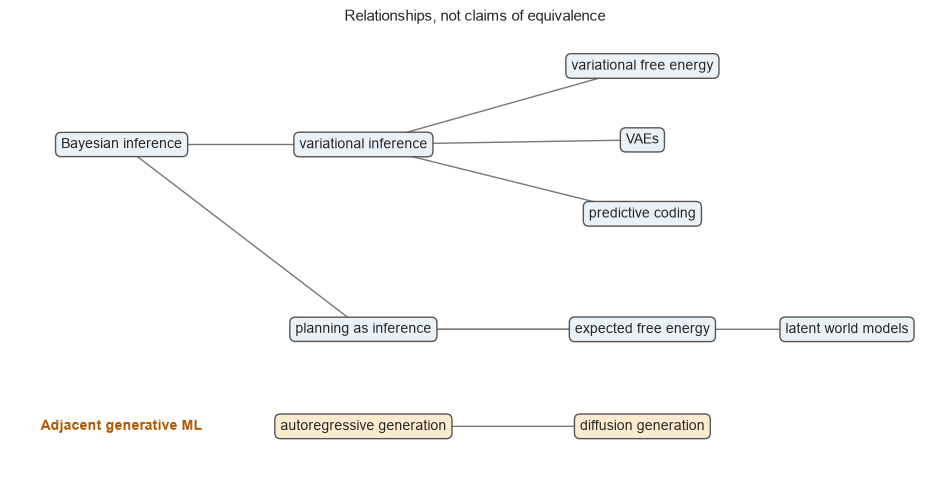

In [51]:
fig, ax = plt.subplots(figsize=(12, 6))
concept_positions = {
    "Bayesian inference": (.12,.75), "variational inference": (.38,.75),
    "variational free energy": (.68,.92), "VAEs": (.68,.76), "predictive coding": (.68,.60),
    "planning as inference": (.38,.35), "expected free energy": (.68,.35),
    "autoregressive generation": (.38,.14), "diffusion generation": (.68,.14),
    "latent world models": (.90,.35),
}
links = [
    ("Bayesian inference","variational inference"),
    ("variational inference","variational free energy"), ("variational inference","VAEs"),
    ("variational inference","predictive coding"), ("Bayesian inference","planning as inference"),
    ("planning as inference","expected free energy"), ("planning as inference","latent world models"),
    ("autoregressive generation","diffusion generation"),
]
for a,b in links:
    ax.annotate("", concept_positions[b], concept_positions[a], arrowprops=dict(arrowstyle="->", color="#777"))
for name,(x0,y0) in concept_positions.items():
    colour = "#FDEBD0" if "generation" in name else "#EAF2F8"
    ax.text(x0,y0,name,ha="center",va="center",bbox=dict(boxstyle="round,pad=.4",fc=colour,ec="#555"))
ax.text(.12,.14,"Adjacent generative ML",ha="center",va="center",fontweight="bold",color="#B05A00")
ax.axis("off"); ax.set_title("Relationships, not claims of equivalence")
plt.show()

### Final scientific reading

- **Use the synthetic system to learn mechanisms and debug inference.** It supplies
  counterfactuals and ground truth that the repository cannot.
- **Use the real UHCS images to test representation robustness and processing signal.**
  Cached MicroNet embeddings and grouped sample metadata make that meaningful now.
- **Do not claim real yield/ductility prediction.** Those labels are absent.
- **Treat real hardness as a feasibility example.** Seven UHCS conditions and nineteen
  distant-label panels cannot calibrate extremes or support property-conditioned generation.
- **The next data milestone is process–structure–property triples**, measured at a split
  unit that represents independent specimens rather than repeated fields of view.

### A productive second pass

1. Predict each plot before rerunning it.
2. Change one causal equation, not five hyperparameters.
3. Hold out a different regime and record what breaks.
4. Replace one synthetic component with real embeddings while preserving grouped splits.
5. For every attractive generated image, demand morphology, diversity, and nearest-neighbour checks.

<div style="border-left:5px solid #2A9D8F;padding:0.65em 1em;background:#faf8fc">
        <b>After you see the output — interpretation checkpoint</b>
        </div>

        **Synthesis.** The common thread is a model of relationships among processing, hidden
state, observations, properties, and actions. Different methods choose different
factorisations, objectives, and inference procedures over that same world.

**A research-quality next step.** Pick one modest claim—for example, “MicroNet embeddings
predict annealing-temperature class beyond magnification confounds”—fix the split and
success criterion before training, and record what result would falsify it.

**Final exercise.** Write one sentence for each model completing: “I would use this when
I need ___, I have ___ data, and I can tolerate ___ failure mode.” If the blanks are
unclear, revisit the corresponding purple boxes rather than tuning the code.

<div style="border-left:4px solid #4C78A8;padding:0.4em 1em;background:#f5f8fc">
<b>What did the model learn?</b> The same material world can be viewed through prediction, inversion, compression, generation, uncertainty, and action.<br>
<b>What did it fail to learn?</b> No modelling paradigm creates missing property measurements or validates an oversimplified simulator.<br>
<b>What would falsify our interpretation?</b> Failure on independent process regimes or new specimens falsifies claims that a method learned transferable material physics.<br>
<b>What should I try next?</b> Choose one concept, write a falsifiable hypothesis, and change only the experiment needed to test it.
</div>